goal of this notebook.
extract rank correlation statistics for each subject

In [1]:
import pathlib
import random
import copy
import numpy as np
import torch

from captum.attr import *
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import yaml
import argparse
from data.data_loader import load_eeg_data, get_sliding_window_data, create_dataloader
import os
import mne
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

from sliced_wasserstein import sliced_wasserstein_distance
from c2st import c2st_knn, c2st_nn, c2st_rf

from models.s4net import S4PatchedFinalNet,TrunkNet, HeadNet

/home/marco/anaconda3/envs/MA_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.


In [2]:
CFG_YAML = """
wandb:
 key: f0c92a0059bf12e2647f0a1c22fdcd12555fa6df
model:
dataset:
 data_directory: /home/marco/Documents/GitHub/tms_eeg_decoding/data
 #file_name: subject_{:03d}_preprocessed_combined_py.fif
 file_name: subject_{:03d}_preprocessed_combined_py.fif
 exclude_timepoints: 100
 subject_index: 1
 test_subject_indices: [1,2,13,24,26,27,29,34,35,41, 42,43,45,46,47,48,52,55,56,57,60,62,67,69,72,73,79,80,86,88,92,102]
 #test_subject_indices: [2]
training:
 training_start_len: 100
 pretrain_epochs: 100
 pretrain_lr: 0.0001
 val_window_len: 1
 epochs_per_window: 10
 num_warmup_epochs: 5
 num_epochs: 800
 slide_step: 1
 num_warmup_epochs_per_window: 0
 lr: 0.005 #maybe change back to 0.0001
 nll_beta: 0.001
 num_warmup_epochs: 0
 batch_size: 50 #better to use 50
 random_seed: 42
 precision: bf16
 kde_lambda: 0.5
 finetune_entire_model: true # Set to true to finetune the entire model, false for transformer only
exp_name: S4_S4EEGNet_ema
"""

def load_config():
    cfg = OmegaConf.create(yaml.safe_load(CFG_YAML))
    cfg.exp_name = f"{cfg.exp_name}_subject_{cfg.dataset.subject_index}"
    return cfg

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--update_conf", nargs="*", help="Updates to the configuration in the form of key=value pairs", default=[])
    parser.add_argument("-f", "--fff", help="A dummy argument to handle IPython's default argument", default="1")
    return parser.parse_args()

def update_config(cfg, cli_args):
    for update in cli_args.update_conf:
        key, value = update.split("=")
        try:
            value = eval(value)
        except:
            pass
        OmegaConf.update(cfg, key, value, force_add=True)
    cfg.exp_name = cfg.exp_name + "_" + "_".join(cli_args.update_conf)
    print(OmegaConf.to_yaml(cfg))
    return cfg


def save_config(cfg):
    os.makedirs("conf/sweeps", exist_ok=True)
    os.makedirs("exp/withinsubs", exist_ok=True)
    with open(f"conf/sweeps/withinsubs_{cfg.exp_name}.yaml", "w") as f:
        f.write(OmegaConf.to_yaml(cfg))

In [3]:
def get_top_channels(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors, top_k=10):
    top_channels_mean = {}
    top_channels_median = {}
    prediction_diff_mean = {}
    prediction_diff_median = {}
    
    for band_name in freq_bands.keys():
        top_channels_mean[band_name] = {}
        top_channels_median[band_name] = {}
        prediction_diff_mean[band_name] = {}
        prediction_diff_median[band_name] = {}
        
        for factor in amplification_factors:
            mean_diffs = mean_diff_per_channel[band_name][factor]
            median_diffs = median_diff_per_channel[band_name][factor]
            
            # Sort the channels based on their differences
            sorted_mean_diffs = sorted(mean_diffs.items(), key=lambda item: item[1], reverse=True)
            sorted_median_diffs = sorted(median_diffs.items(), key=lambda item: item[1], reverse=True)
            
            # Select the top k channels
            top_channels_mean[band_name][factor] = [ch for ch, _ in sorted_mean_diffs[:top_k]]
            top_channels_median[band_name][factor] = [ch for ch, _ in sorted_median_diffs[:top_k]]
            
            # Store the prediction differences for the top k channels
            prediction_diff_mean[band_name][factor] = {ch: mean_diffs[ch] for ch in top_channels_mean[band_name][factor]}
            prediction_diff_median[band_name][factor] = {ch: median_diffs[ch] for ch in top_channels_median[band_name][factor]}
    
    return top_channels_mean, top_channels_median, prediction_diff_mean, prediction_diff_median


In [16]:
import pickle

def load_predicted_amplitude_for_subject(subject_index=2, rep=2):
    data_dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/gradshap_explanations_rep_{rep}"
    file_path = os.path.join(data_dir, f"gradshap_data_subject_{subject_index}_rep_{rep}.npy")

    subject_data = np.load(file_path, allow_pickle=True).item()
    predictions, uncertainties, explanations = subject_data['predictions'], subject_data['uncertainties'], subject_data['explanations']

        
    cfg = load_config()
    cfg.dataset.subject_index = subject_index
    _, _, _, _, _, _, _, ch_names = load_eeg_data(cfg)
    
    return predictions, uncertainties, explanations, ch_names

In [14]:
def load_subject_topk(subject_index=2, rep=2):
    #load_dir = f"/home/marco/Documents/GitHub/tms_eeg_decoding/subject_interpretability/"
    file_name = f"all_subject_channel_importances_gradshap_abs_rep_{rep}.npy"

    topk = np.load(file_name, allow_pickle=True).item()
    return topk[subject_index]

In [6]:
def get_top_k_keys(d, k):
    """
    Returns the top k keys in a dictionary that have the highest values.

    Parameters:
    d (dict): The input dictionary.
    k (int): The number of top keys to return.

    Returns:
    list: A list of the top k keys with the highest values.
    """
    # Sort the dictionary by values in descending order and get the top k keys
    top_k_keys = sorted(d, key=d.get, reverse=True)[:k]
    return top_k_keys

# Example usage
d = {'a': 10, 'b': 20, 'c': 15, 'd': 5, 'e': 25}
k = 3
print(get_top_k_keys(d, k))  # Output: ['e', 'b', 'c']

['e', 'b', 'c']


In [20]:

def calculate_diff_per_channel(pred_label_original, freq_bands, amplification_factors, ch_names, subject_index=2, rep=2):
    dir_constrained = "/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/parallel_perturbation_power"
    mean_diff_per_channel = {}
    median_diff_per_channel = {}

    for band_name, (low_freq, high_freq) in freq_bands.items():
        mean_diff_per_channel[band_name] = {}
        median_diff_per_channel[band_name] = {}
        for factor in amplification_factors:
            file_path = f"parallel_perturbed_prediction_dict_{band_name}_channel_amp_factor_{factor}_subject_{subject_index}_rep_{rep}.npy"
            load_path = os.path.join(dir_constrained, file_path)
            perturbed_data = np.load(load_path, allow_pickle=True).item()
            mean_diff_per_channel[band_name][factor] = {}
            median_diff_per_channel[band_name][factor] = {}
            for ch_name in ch_names:
                perturbed_amplitude = perturbed_data[ch_name]
                diff = np.abs(pred_label_original - perturbed_amplitude)
                mean_diff_per_channel[band_name][factor][ch_name] = np.mean(diff)
                median_diff_per_channel[band_name][factor][ch_name] = np.median(diff)
    
    return mean_diff_per_channel, median_diff_per_channel

In [8]:
freq_bands = {
              "delta": (0, 4),
              "theta": (0, 4),             
              "alpha": (8, 12),
              "beta": (12, 30),
              "gamma": (30, 45)}

amplification_factors = [0.5,0.8,0.9,1.1,1.2,1.5]

In [9]:
original_predictions, _, explanations, ch_names = load_predicted_amplitude_for_subject(subject_index=2)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


In [19]:
original_predictions.shape

(571,)

In [10]:

mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, amplification_factors , ch_names)
top_channels_mean, top_channels_median, prediction_diff_mean, prediction_diff_median = get_top_channels(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors , top_k=10)


In [21]:
# not adpated yes to REPEITTIONS
#top_channels_top_k = load_subject_topk(subject_index=2)
#top_channels_top_k_2 = get_top_k_keys(top_channels_top_k, 10)

# top 10 comparison all subjects

In [9]:
def calculate_agreement_top_channels(top_channels_median, top_channels_top_k_2, freq_bands, amplification_factors):
    """
    Calculate the agreement ratio of top channels between absolute prediction difference and interpretability method.

    Parameters:
    top_channels_median (dict): Dictionary containing top channels based on median differences.
    top_channels_top_k_2 (list): List of top channels from interpretability method.
    freq_bands (dict): Dictionary of frequency bands.
    amplification_factors (list): List of amplification factors.

    Returns:
    dict: Agreement results for each frequency band and amplification factor.
    """
    # Initialize a dictionary to store the agreement results
    agreement_results = {}

    # Iterate over each frequency band
    for band_name in freq_bands.keys():
        agreement_results[band_name] = {}
        for factor in amplification_factors:
            # Extract the top 10 channels from top_channels_median for the current band and factor
            top_channels_median_band_factor = top_channels_median[band_name][factor]
            
            # Check the number of top channels that agree
            agreement_count = sum(1 for ch in top_channels_top_k_2 if ch in top_channels_median_band_factor)
            
            # Calculate the agreement ratio
            agreement_ratio = agreement_count / 10.0
            
            # Store the result
            agreement_results[band_name][factor] = agreement_ratio

    return agreement_results

def plot_agreement_matrix(agreement_results):
    """
    Plot the agreement matrix.

    Parameters:
    agreement_results (dict): Agreement results for each frequency band and amplification factor.
    """
    # Prepare data for plotting
    bands = list(agreement_results.keys())
    factors = list(agreement_results[bands[0]].keys())
    agreement_matrix = np.zeros((len(bands), len(factors)))

    for i, band in enumerate(bands):
        for j, factor in enumerate(factors):
            agreement_matrix[i, j] = agreement_results[band][factor]

    # Plot the agreement matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    cax = ax.matshow(agreement_matrix, cmap='viridis')

    # Add color bar
    fig.colorbar(cax)

    # Set axis labels
    ax.set_xticks(np.arange(len(factors)))
    ax.set_yticks(np.arange(len(bands)))
    ax.set_xticklabels(factors)
    ax.set_yticklabels(bands)

    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="left", rotation_mode="anchor")

    # Add text annotations
    for i in range(len(bands)):
        for j in range(len(factors)):
            text = ax.text(j, i, f"{agreement_matrix[i, j]:.2f}", ha="center", va="center", color="white")

    ax.set_xlabel('Phase shifts')
    ax.set_ylabel('Frequency Bands')
    ax.set_title('Agreement Top 10 channels by absolute prediction difference and Top 10 channels of interpretability method')
    fig.savefig('agreement_matrix_top_k_Difference_and_XAI.png')
    plt.show()


#agreement_results = calculate_agreement_top_channels(top_channels_median, top_channels_top_k_2, freq_bands, amplification_factors)

#plot_agreement_matrix(agreement_results)

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


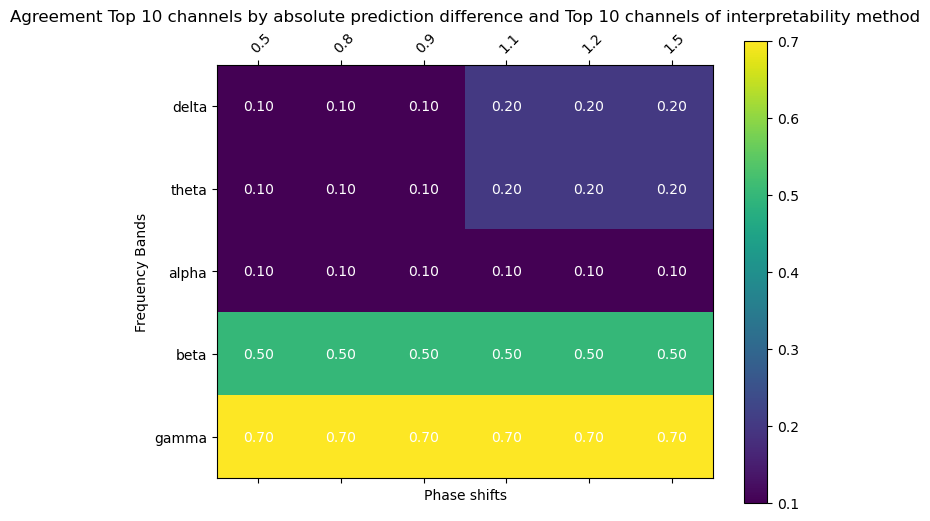

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


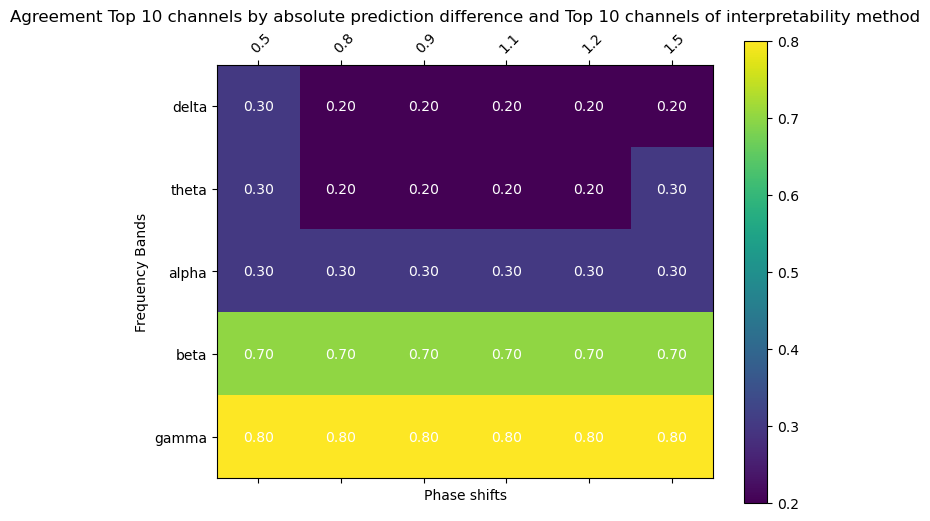

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


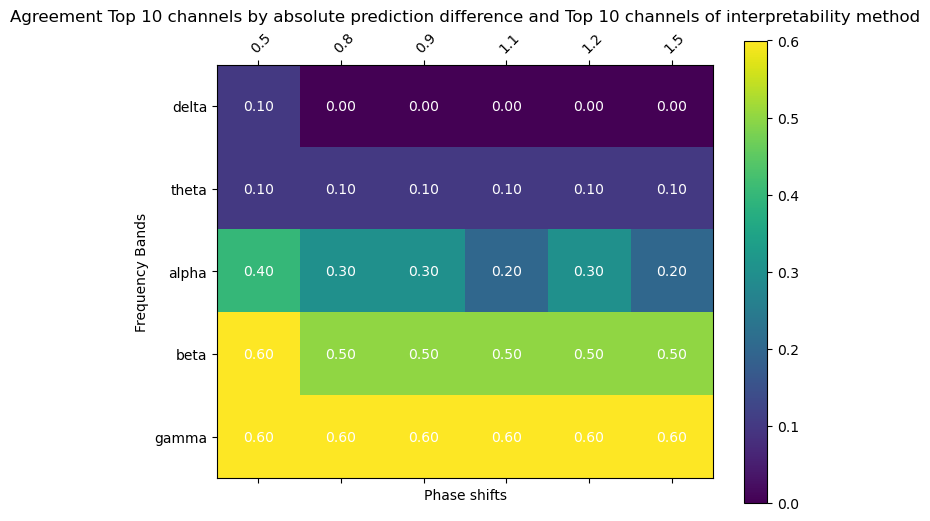

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


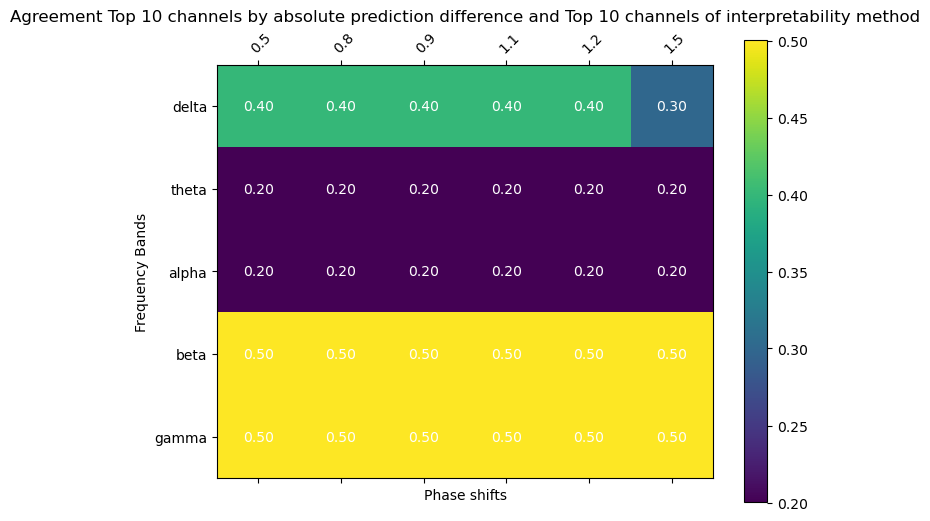

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


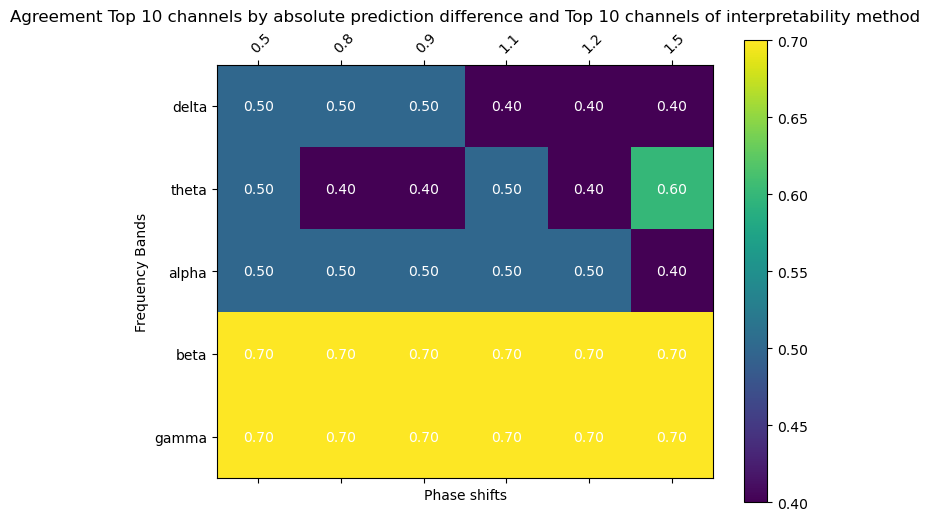

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


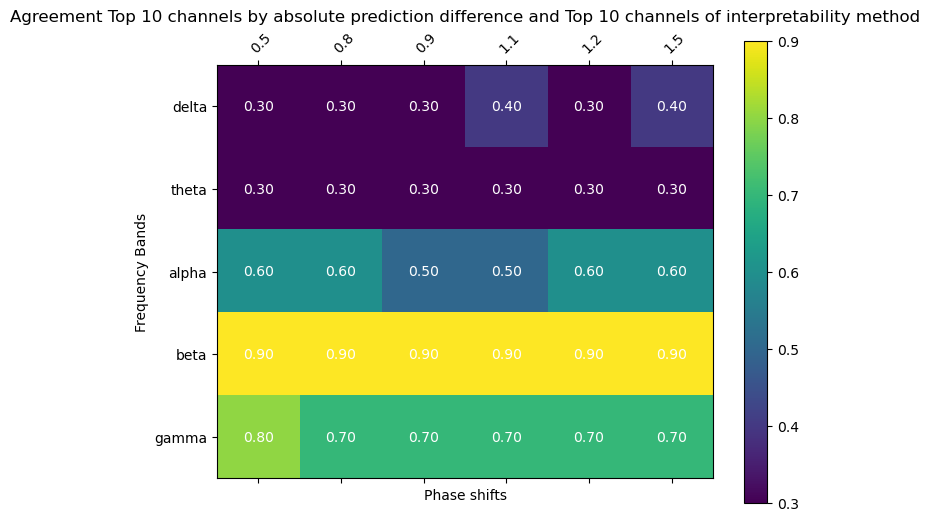

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


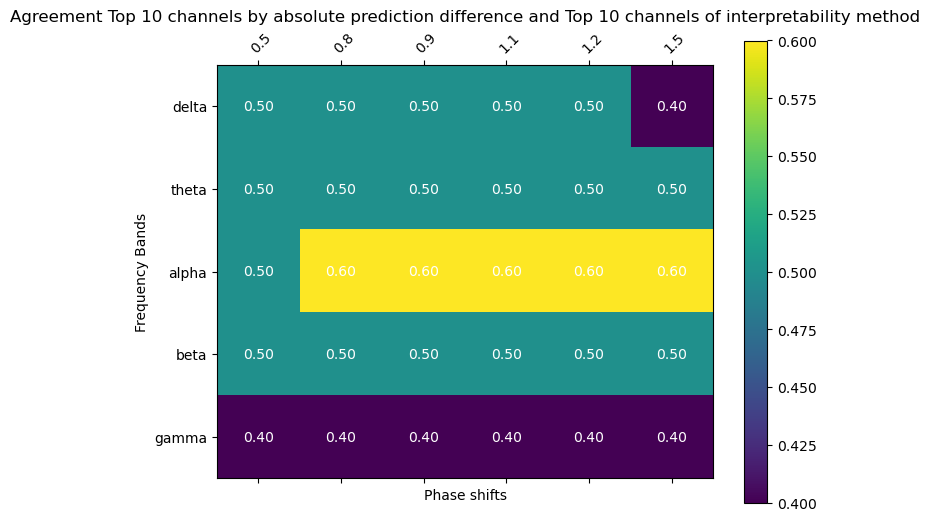

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


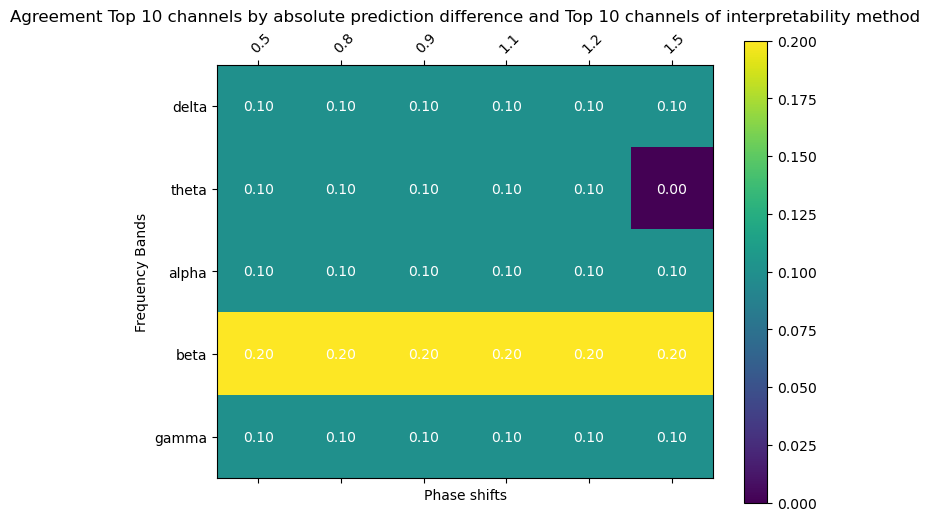

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


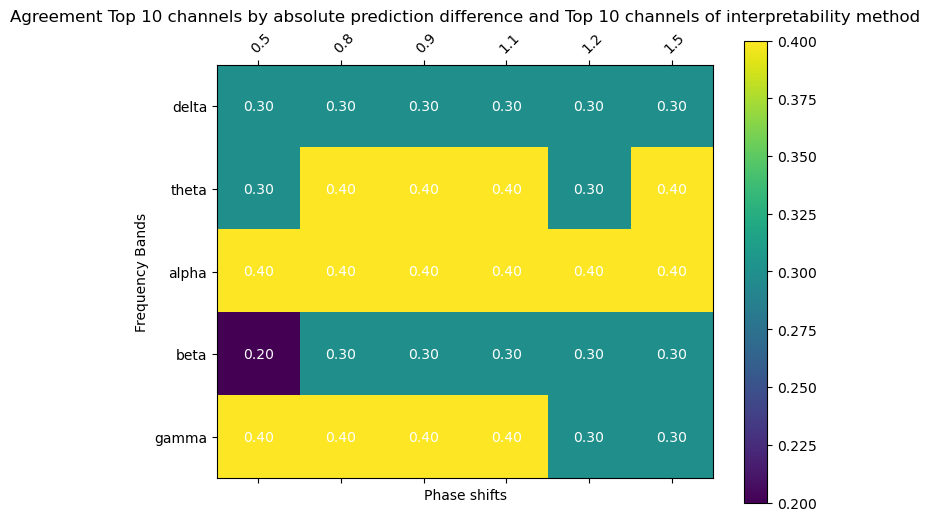

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


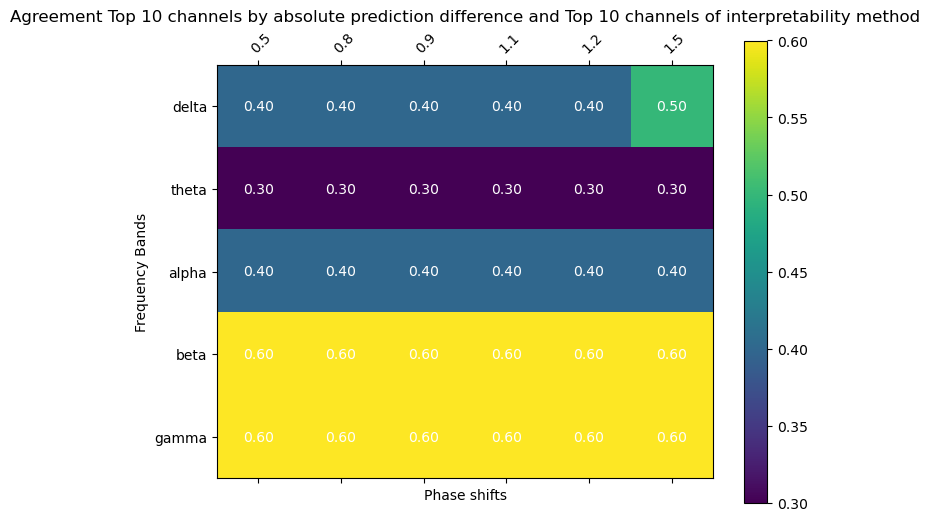

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


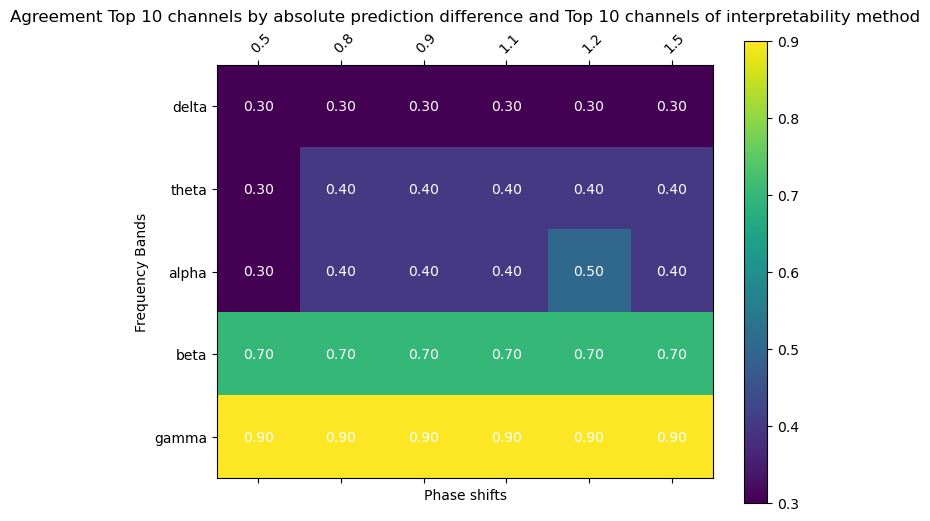

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


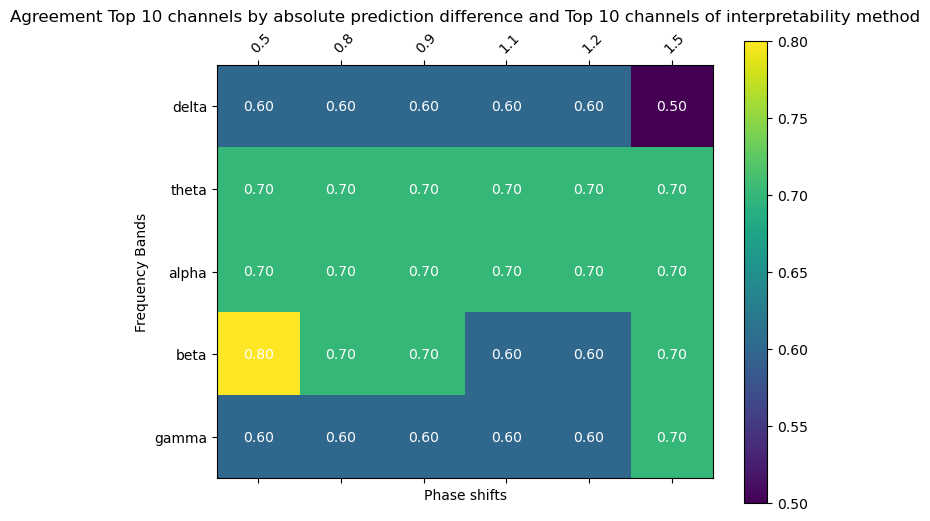

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


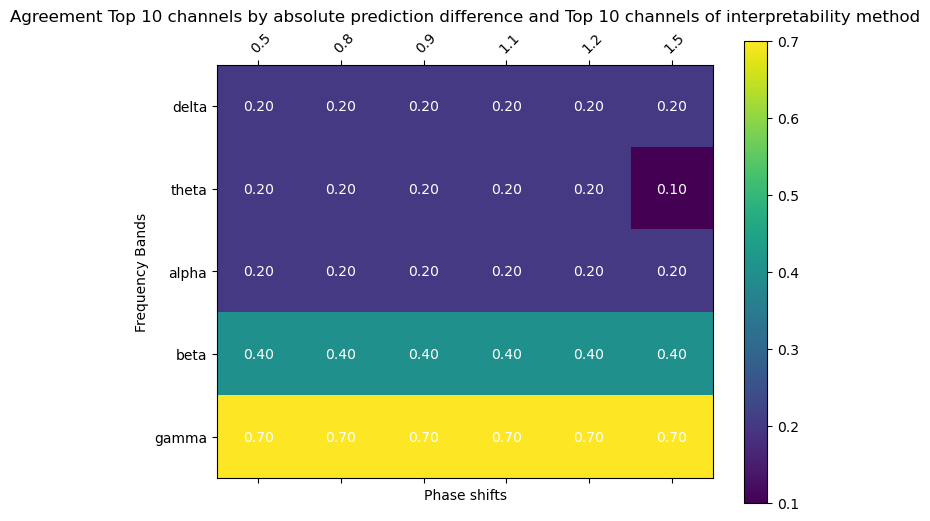

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


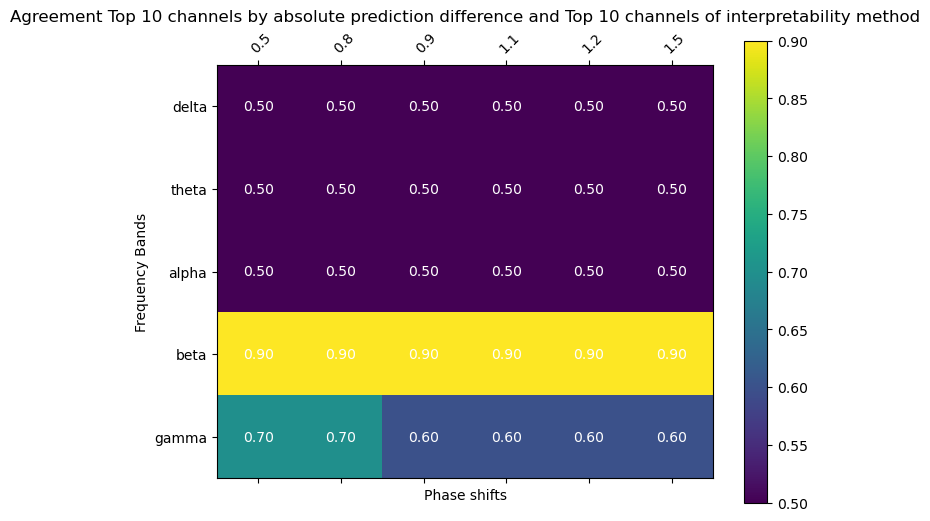

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


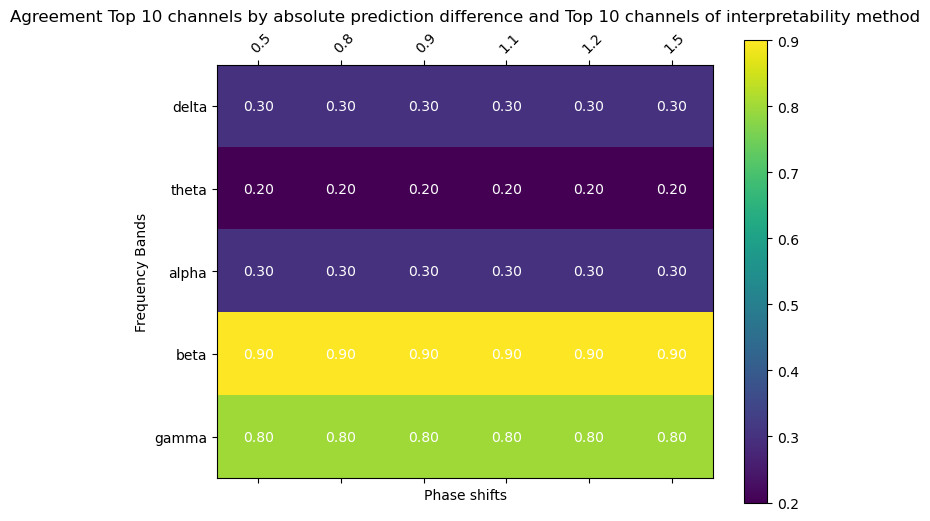

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


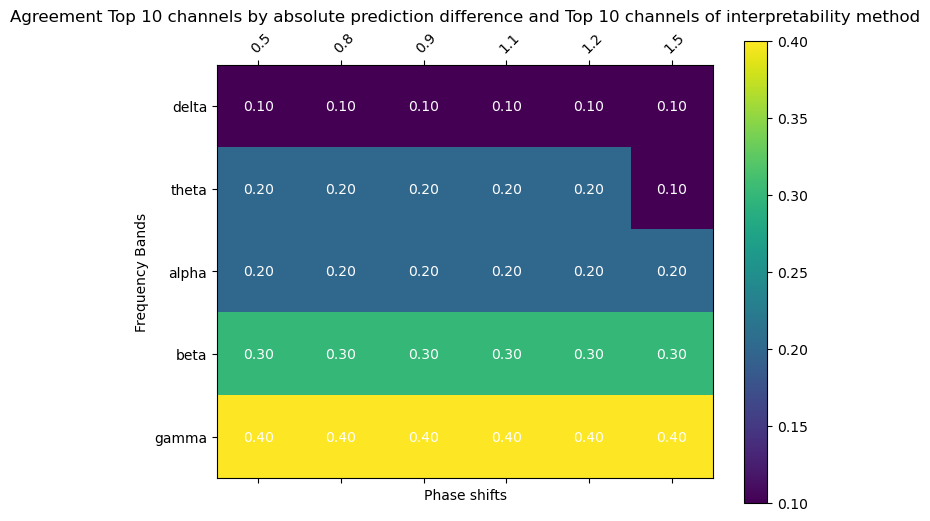

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


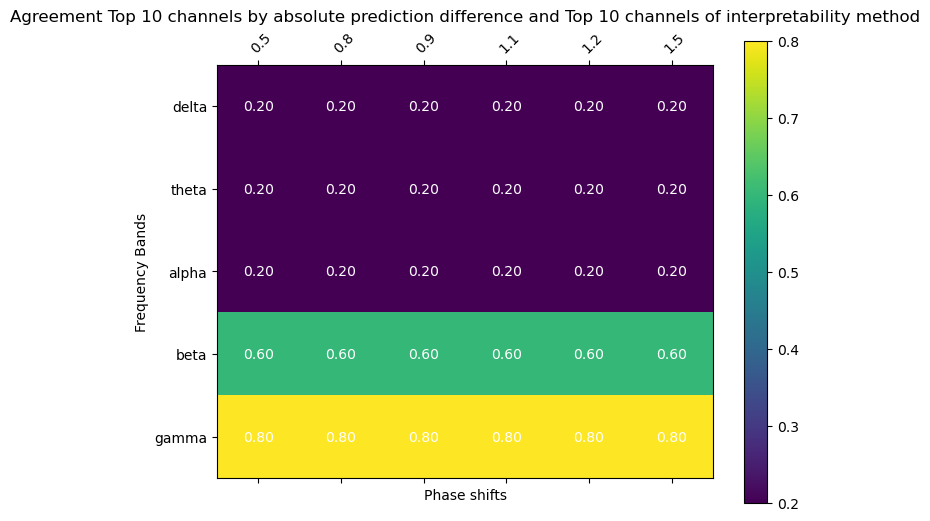

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


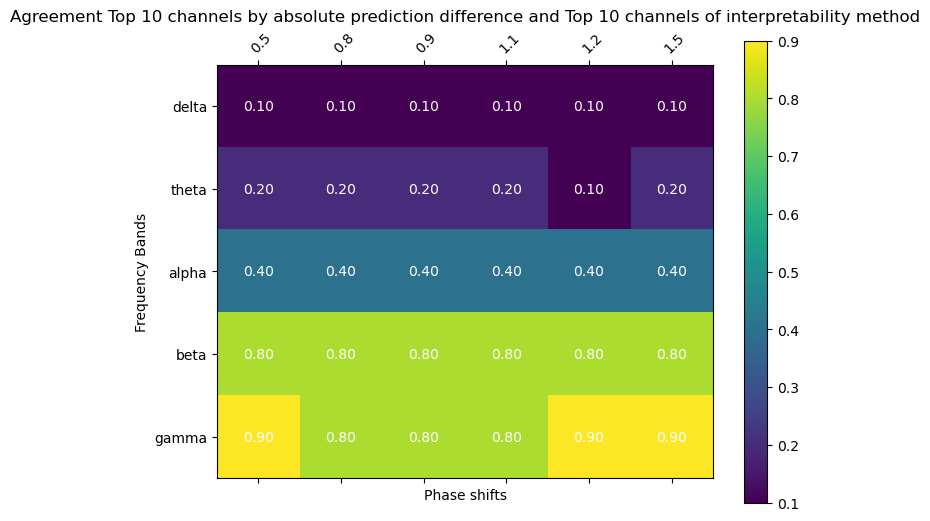

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


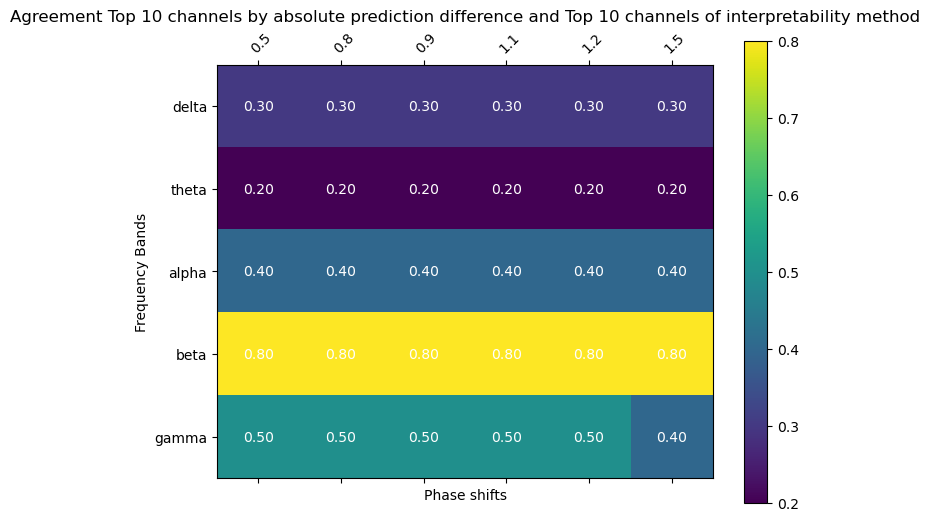

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


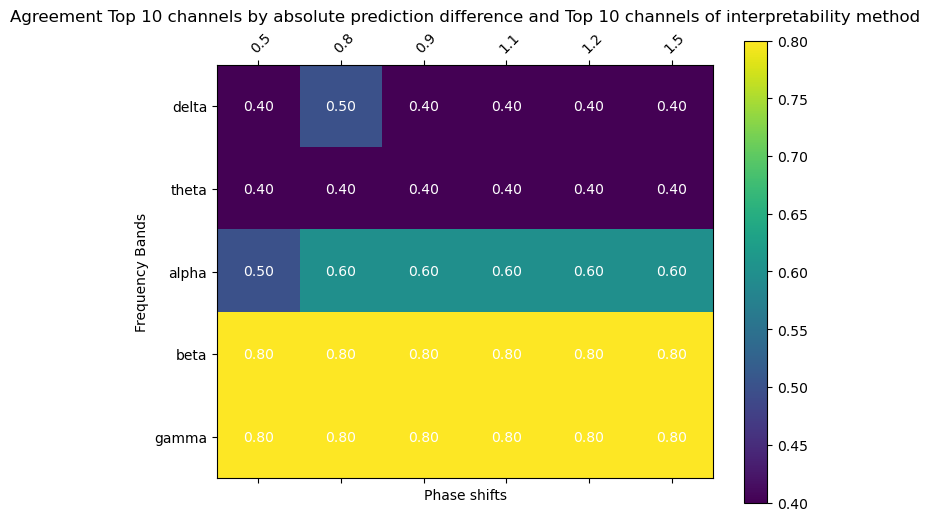

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


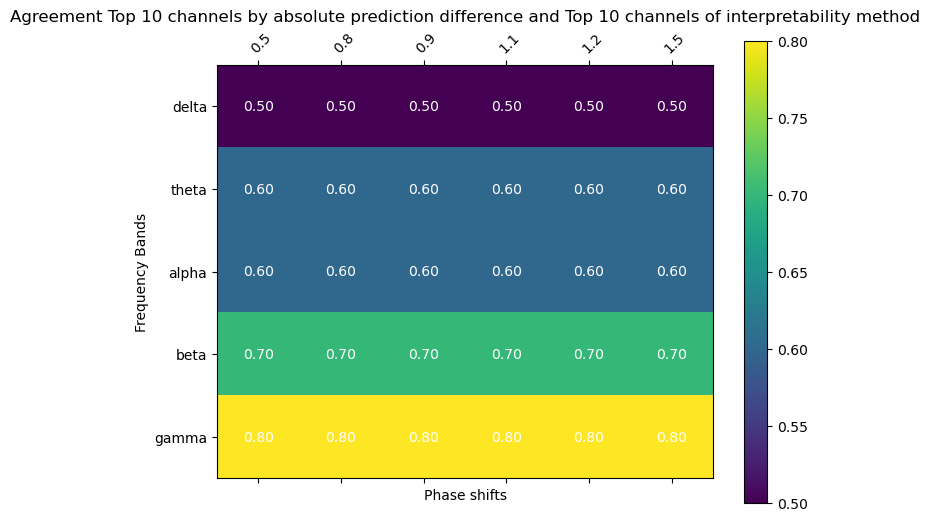

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


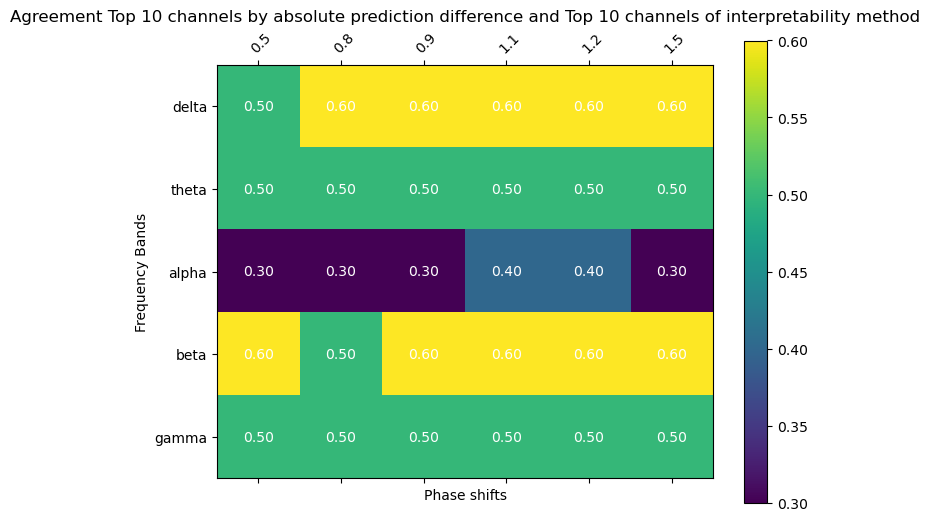

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


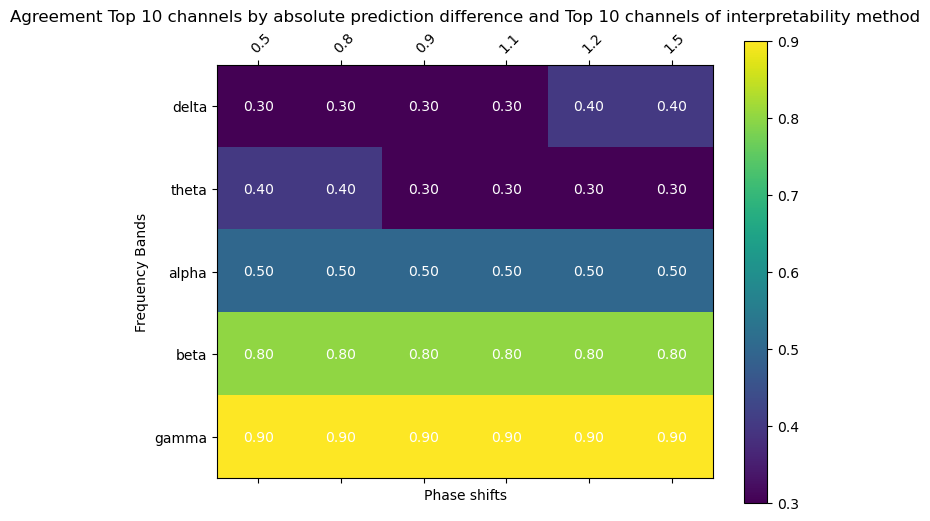

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


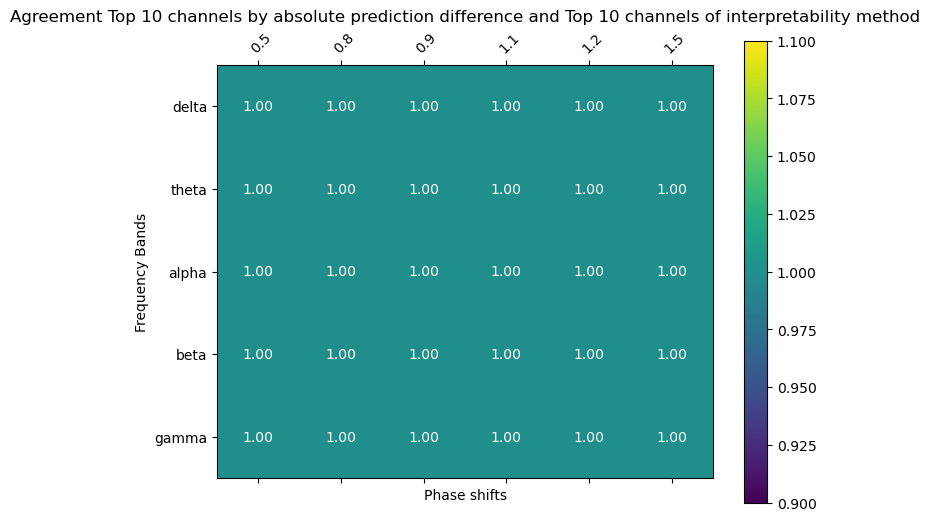

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


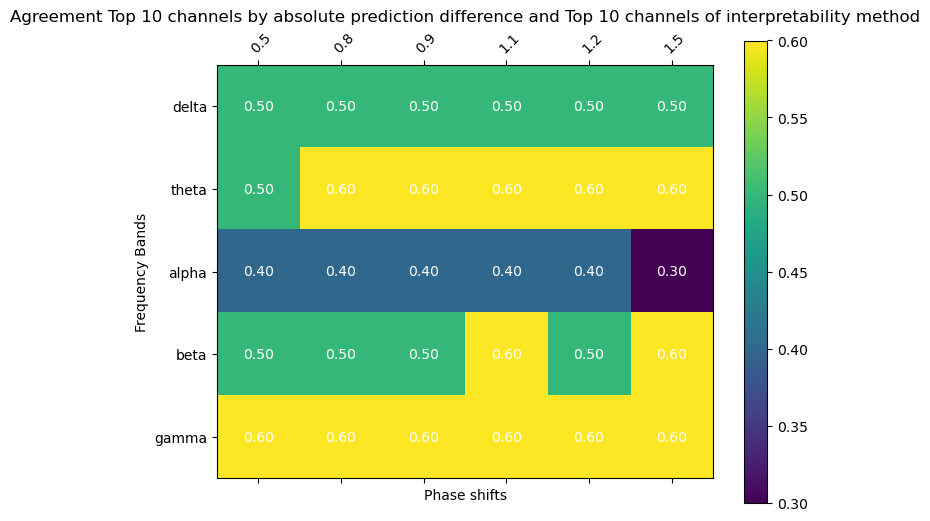

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


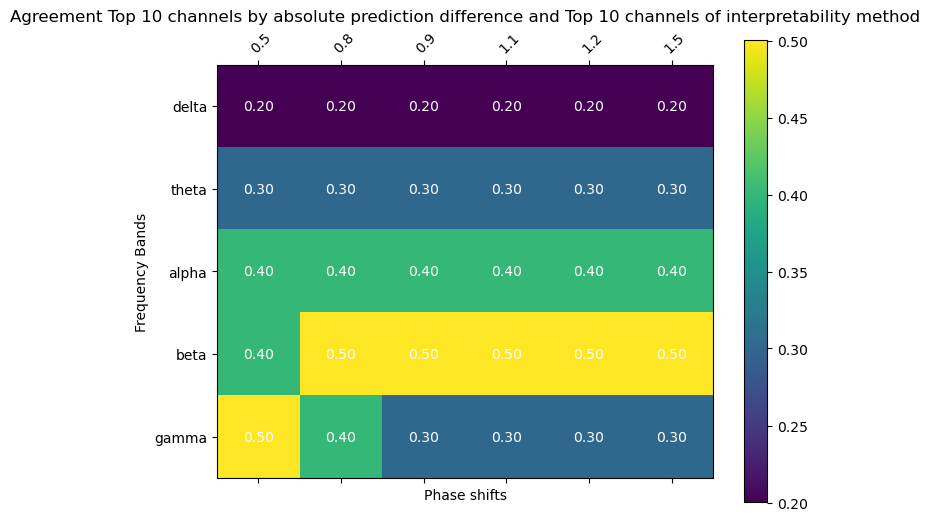

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


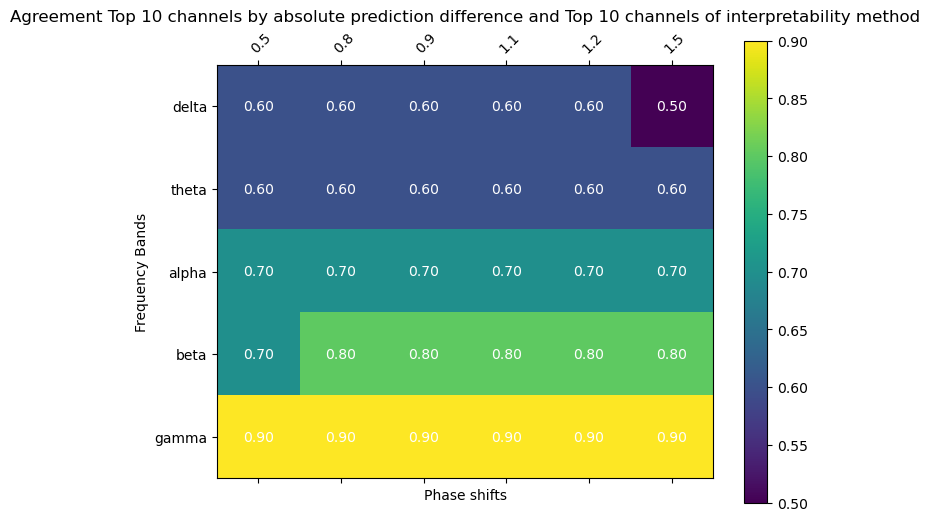

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


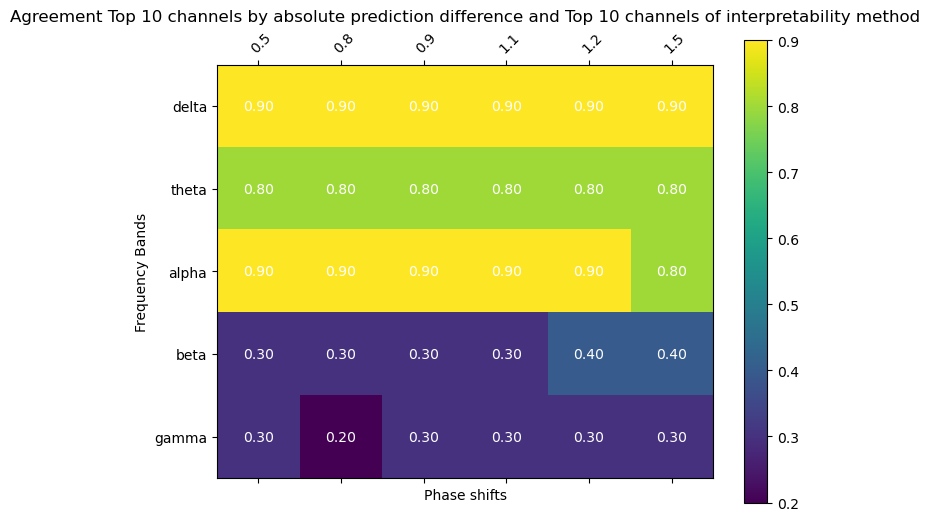

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


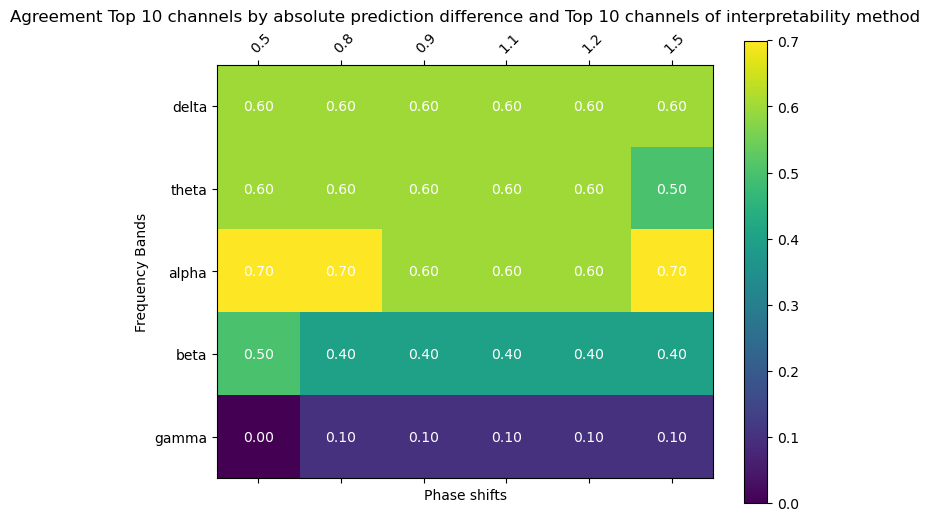

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


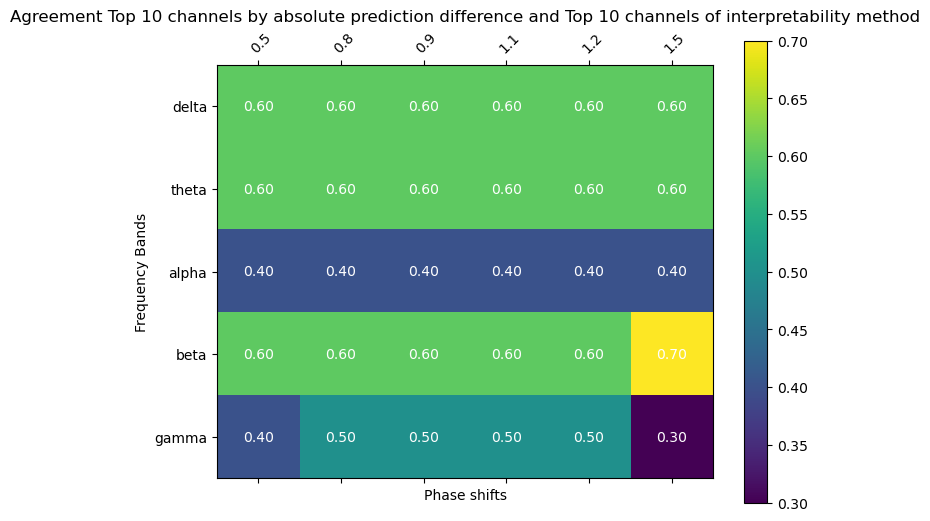

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


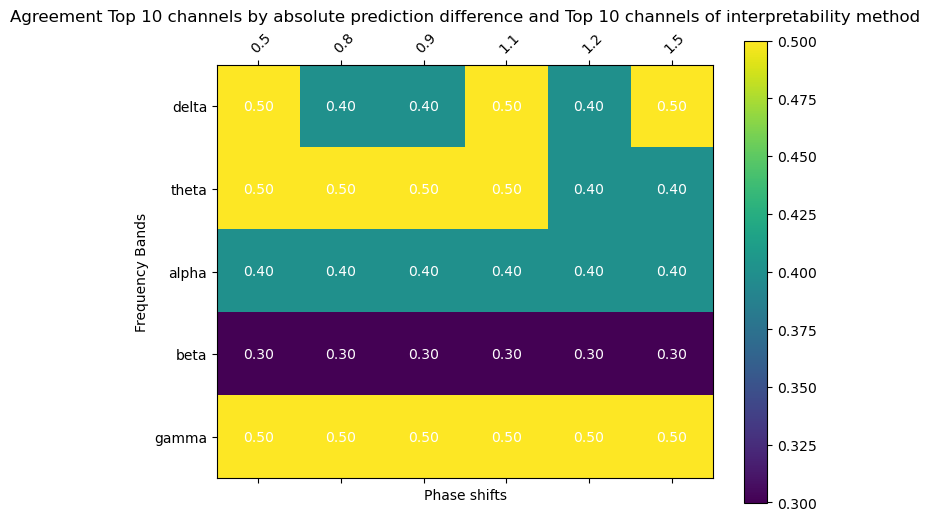

Loading EEG data...
(100, 60, 900)
(1, 60, 1)


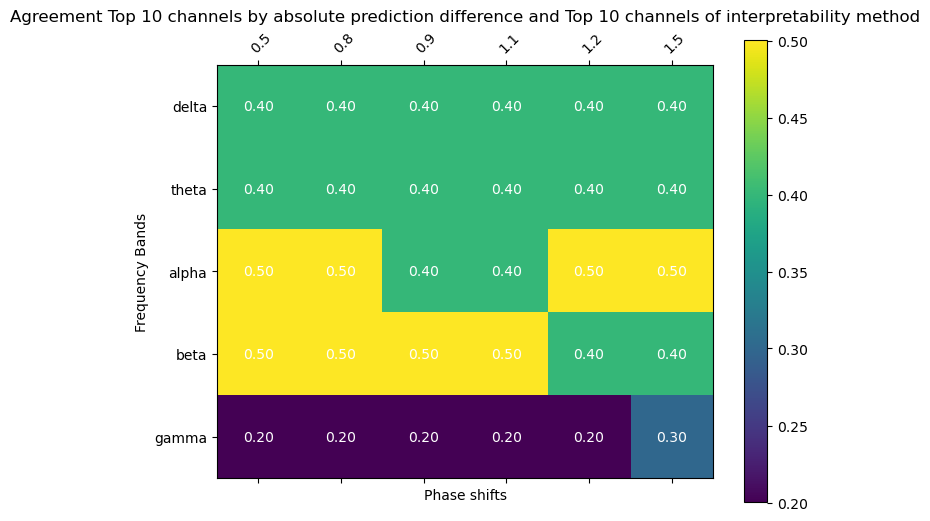

In [10]:
cfg = load_config()
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, _, explanations, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=4)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, amplification_factors, ch_names, subject_index=subject_index, rep=4)
    top_channels_mean, top_channels_median, prediction_diff_mean, prediction_diff_median = get_top_channels(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors, top_k=10)
    top_channels_top_k = load_subject_topk(subject_index=subject_index, rep=4)
    top_channels_top_k_i = get_top_k_keys(top_channels_top_k, 10)
    agreement_results = calculate_agreement_top_channels(top_channels_median, top_channels_top_k_i, freq_bands, amplification_factors)
    plot_agreement_matrix(agreement_results)
    


# rank correlation all subjects

In [11]:

def get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors):
    prediction_diff_mean = {}
    prediction_diff_median = {}
    
    for band_name in freq_bands.keys():
        prediction_diff_mean[band_name] = {}
        prediction_diff_median[band_name] = {}
        
        for factor in amplification_factors:
            mean_diffs = mean_diff_per_channel[band_name][factor]
            median_diffs = median_diff_per_channel[band_name][factor]
            
            # Store the prediction differences without sorting
            prediction_diff_mean[band_name][factor] = mean_diffs
            prediction_diff_median[band_name][factor] = median_diffs
    
    return prediction_diff_mean, prediction_diff_median

#prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, #median_diff_per_channel, freq_bands, amplification_factors)

In [12]:
#top_channels_top_k = load_subject_topk(subject_index=2, rep=4)

In [13]:
from scipy.stats import pearsonr

def calculate_and_plot_rank_correlation(top_channels_top_k, prediction_diff_mean_unsorted, freq_bands):
    """
    Calculate and plot the Pearson rank correlation between top-k channels and prediction differences for each amplification factor.

    Parameters:
    top_channels_top_k (dict): Dictionary of top-k channels.
    prediction_diff_mean_unsorted (dict): Dictionary of unsorted prediction differences.
    freq_bands (dict): Dictionary of frequency bands.
    """
    # Extract the values of top_k_60 for subject 2
    top_k_60_values = list(top_channels_top_k.values())

    # Initialize a dictionary to store the correlation results
    correlation_results = {factor: {} for factor in amplification_factors}

    # Iterate over each amplification factor
    for factor in amplification_factors:
        # Iterate over each frequency band
        for band_name in freq_bands.keys():
            # Extract the values of prediction_diff_mean_unsorted for the current band and factor
            prediction_diff_values = list(prediction_diff_mean_unsorted[band_name][factor].values())
            
            # Compute the Pearson rank correlation
            correlation, p_val = pearsonr(top_k_60_values, prediction_diff_values)
            
            # Store the result
            correlation_results[factor][band_name] = (correlation, p_val)

    # Plot the correlation results
    fig, axes = plt.subplots(1,len(amplification_factors), figsize=(20, 6), sharex=True)
    if len(amplification_factors) == 1:
        axes = [axes]

    for i, factor in enumerate(amplification_factors):
        bands = list(correlation_results[factor].keys())
        correlations = [correlation_results[factor][band][0] for band in bands]
        p_values = [correlation_results[factor][band][1] for band in bands]

        ax = axes[i]
        ax.bar(bands, correlations, color='skyblue', alpha=0.7)
        ax.set_ylabel('Pearson Rank Correlation')
        ax.set_title(f'Amplification Factor: {factor}')

        # Add text annotations for p-values
        for j, p_val in enumerate(p_values):
            ax.text(j, correlations[j] + 0.02, f'p={p_val:.3f}', ha='center', va='bottom', fontsize=10)

    axes[-1].set_xlabel('Frequency Bands')
    fig.suptitle('Pearson Rank Correlation between Top-K Channels and Prediction Differences')
    plt.savefig("Rank_correlation_top_k_abs_all_factors.png")
    plt.show()

# Example usage
#calculate_and_plot_rank_correlation(top_channels_top_k, prediction_diff_mean_unsorted, freq_bands)

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_001_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_001_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
510 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


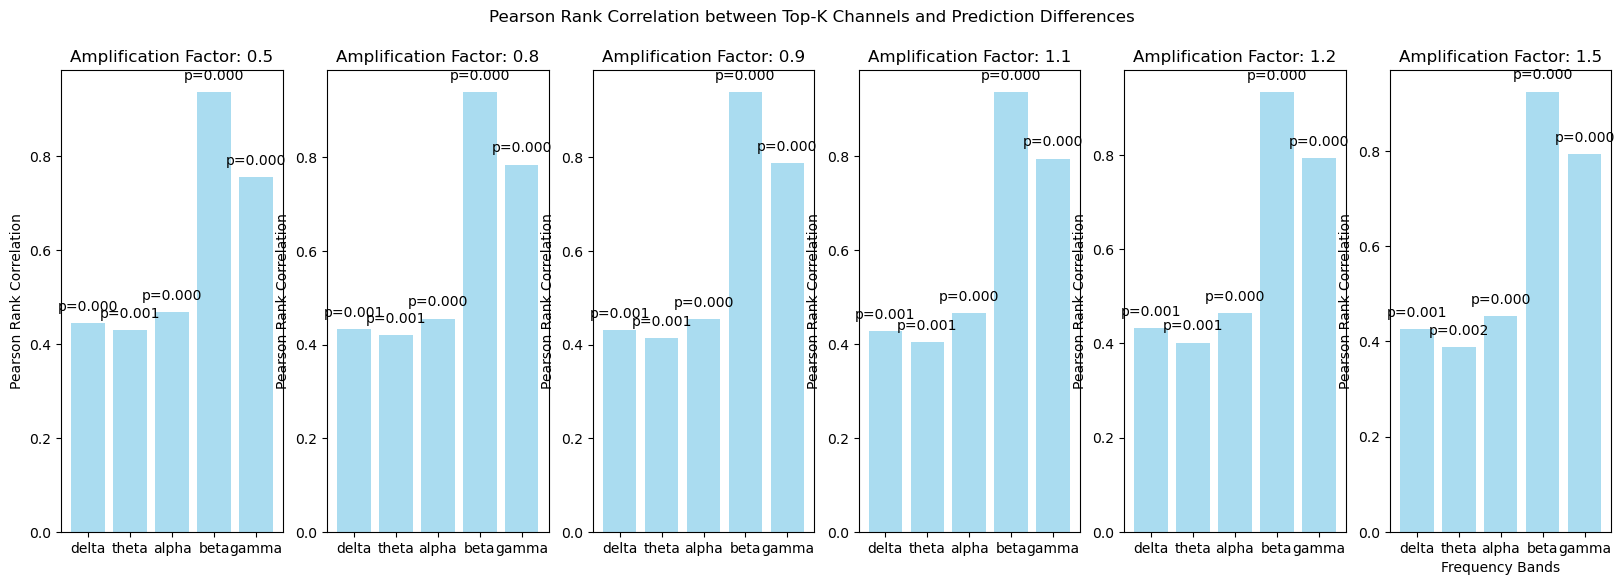

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
721 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


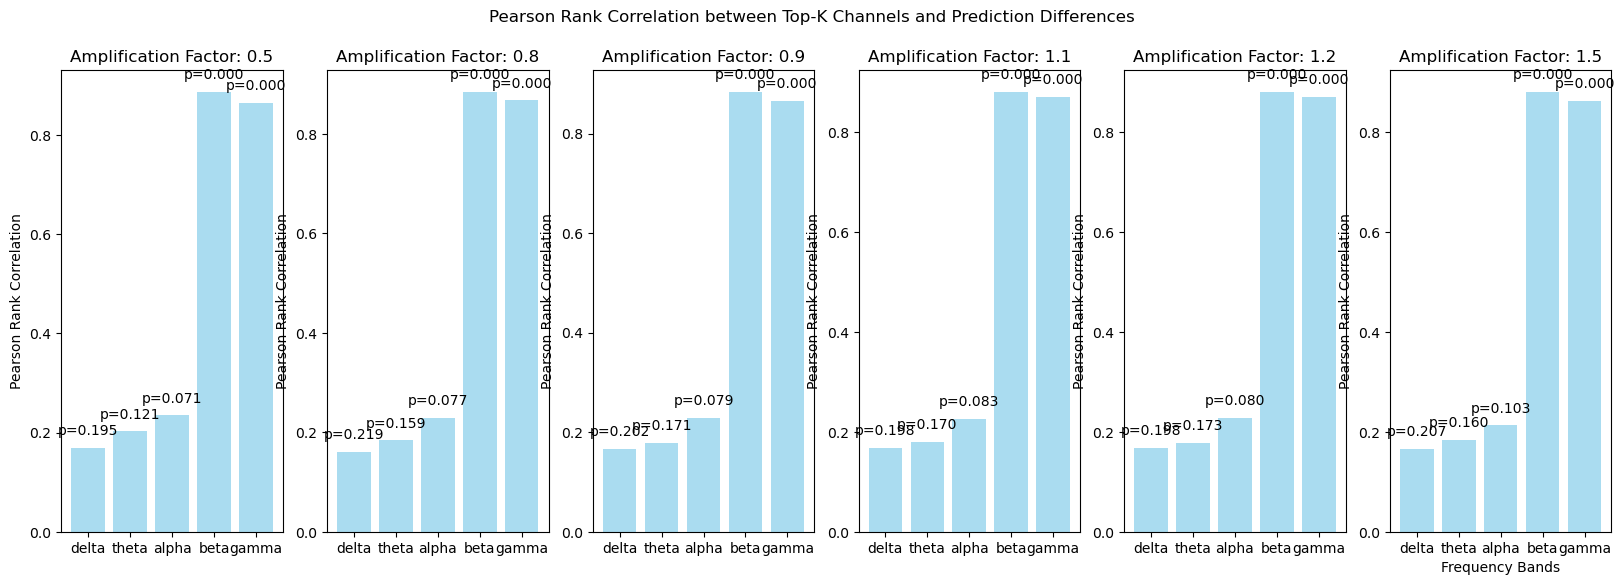

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_013_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_013_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
633 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


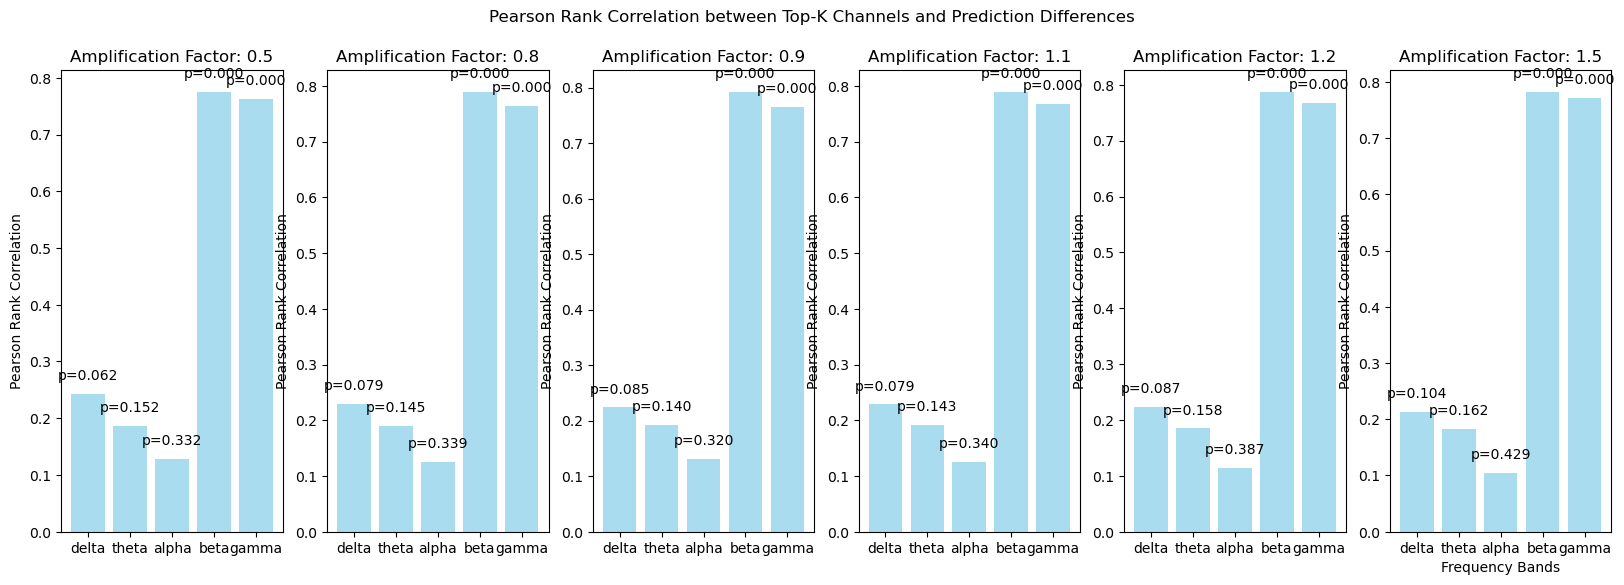

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_024_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_024_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
535 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


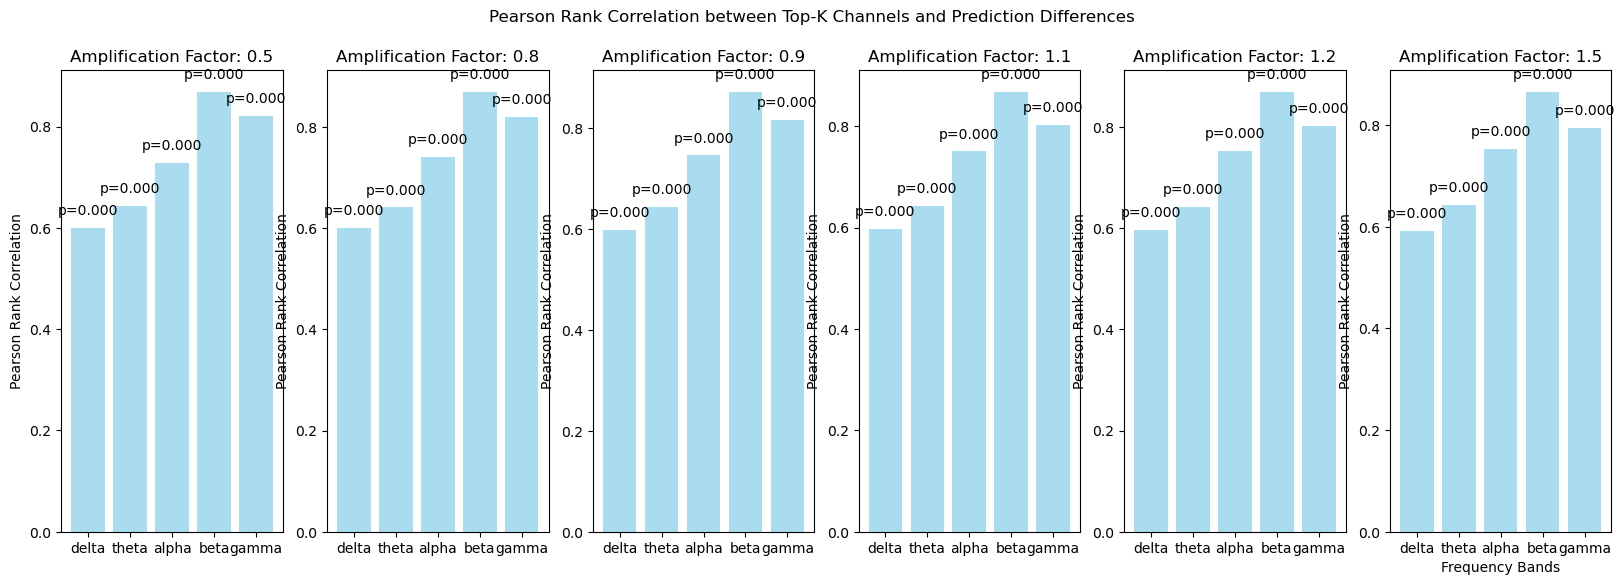

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_026_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_026_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
603 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


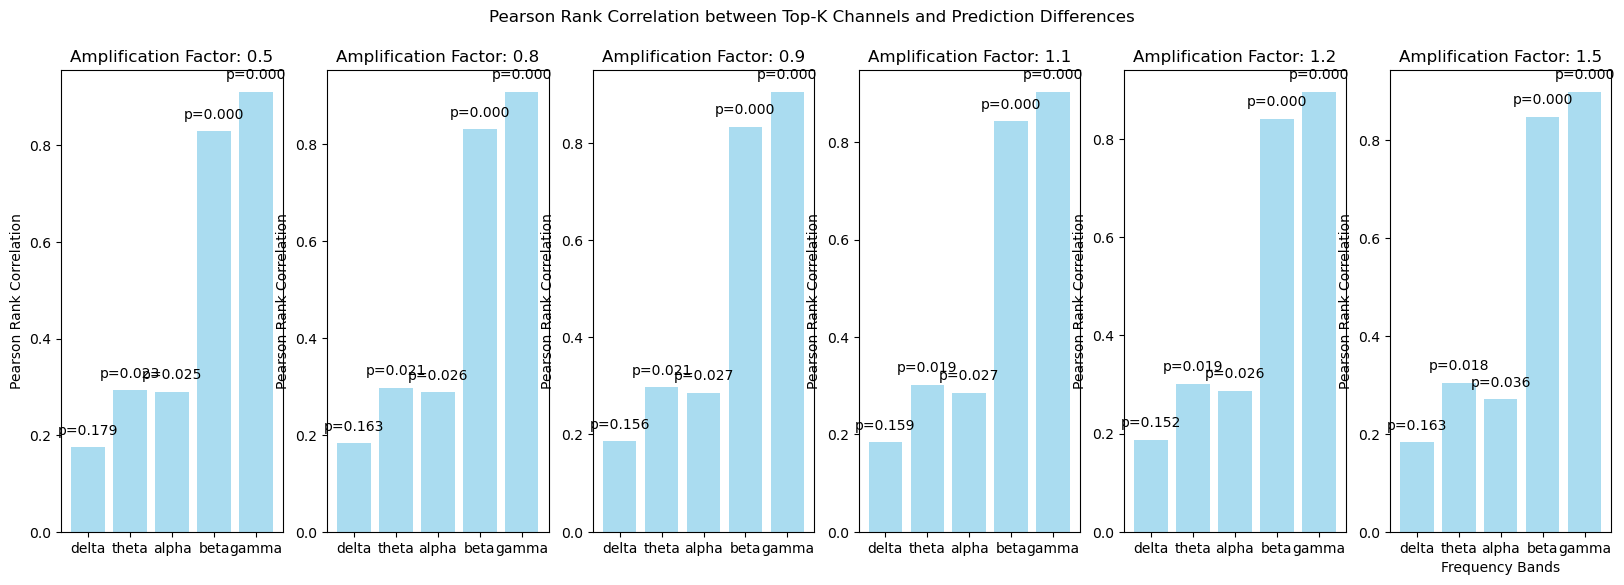

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_027_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_027_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
525 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


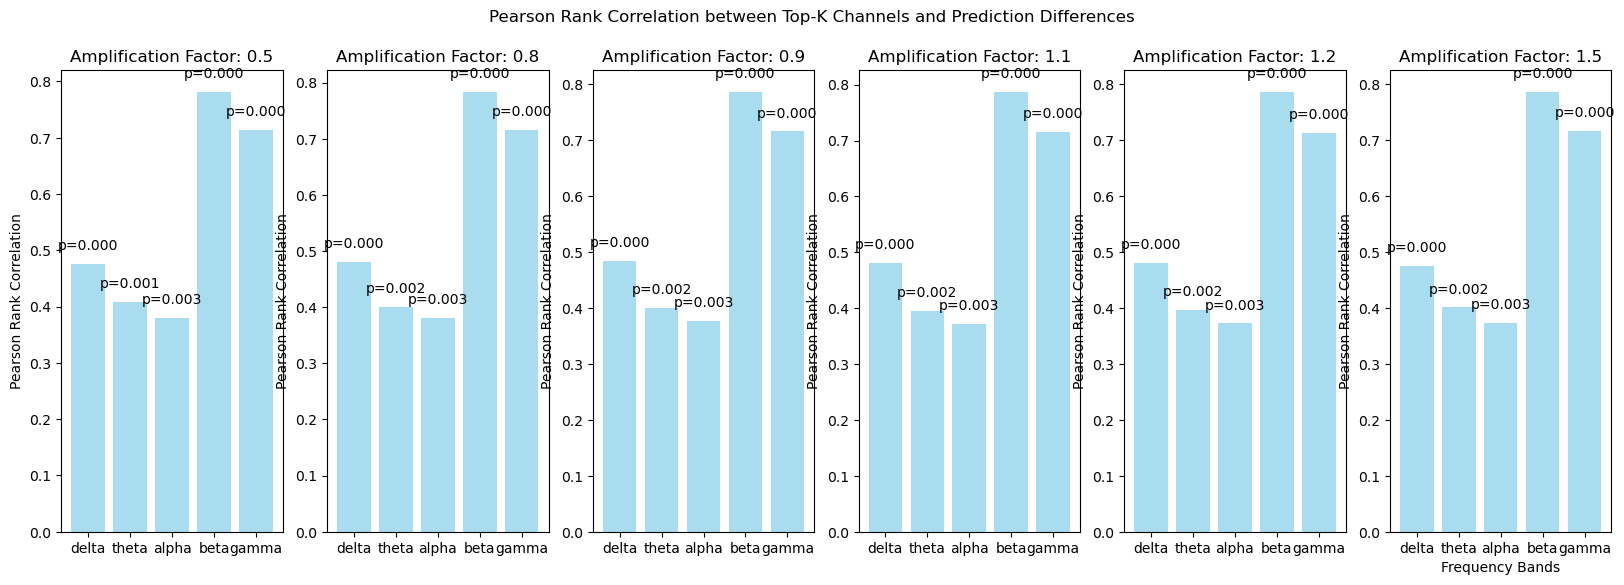

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_029_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_029_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
731 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


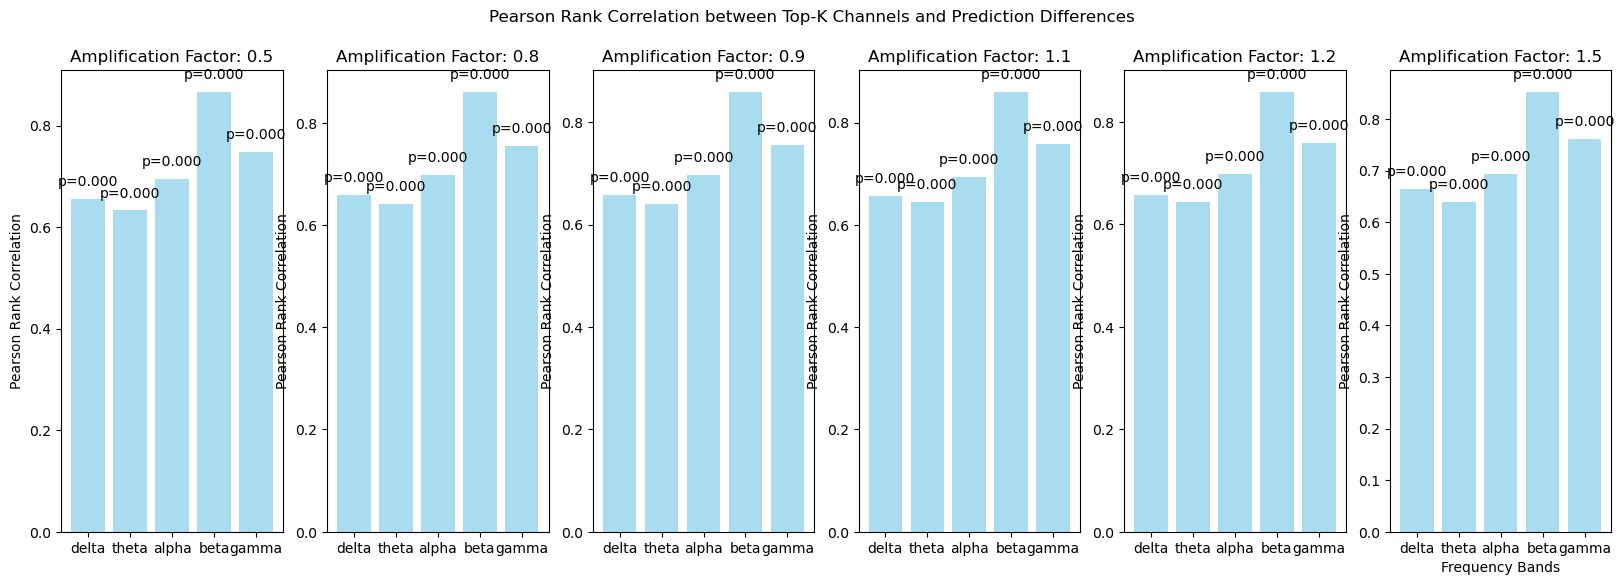

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_034_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_034_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
784 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


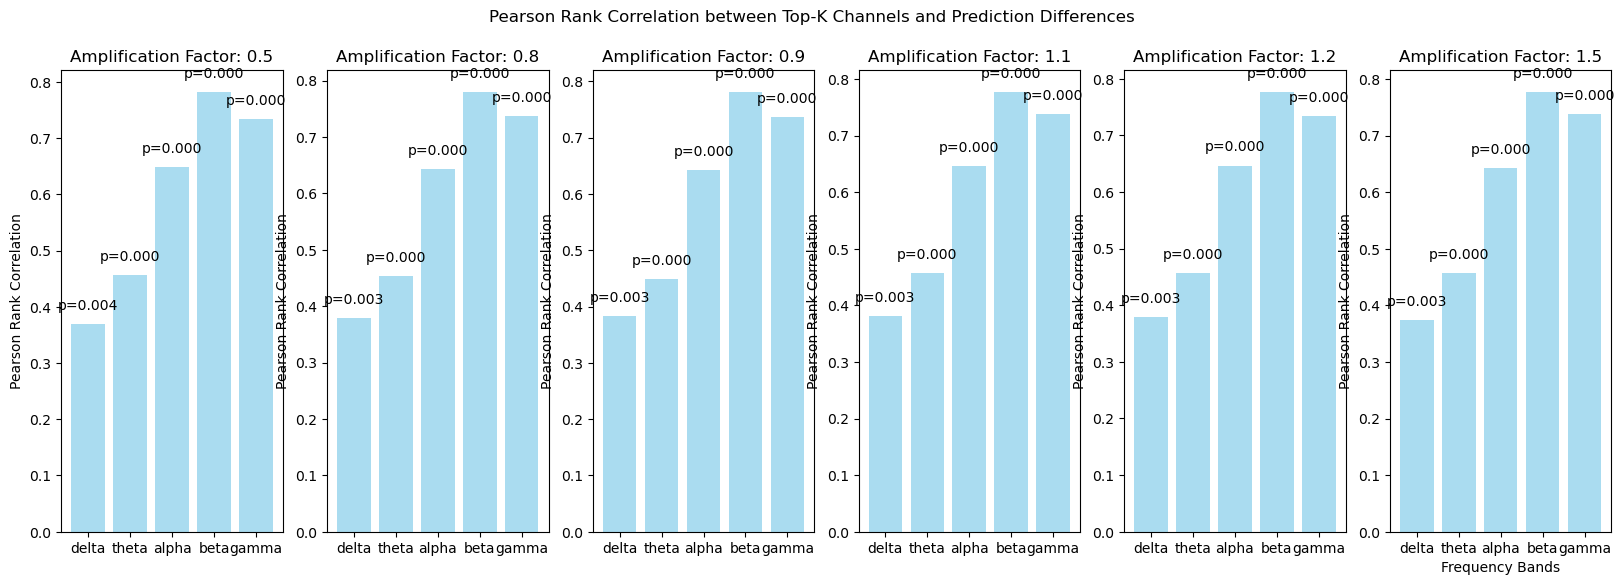

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_035_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_035_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
523 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


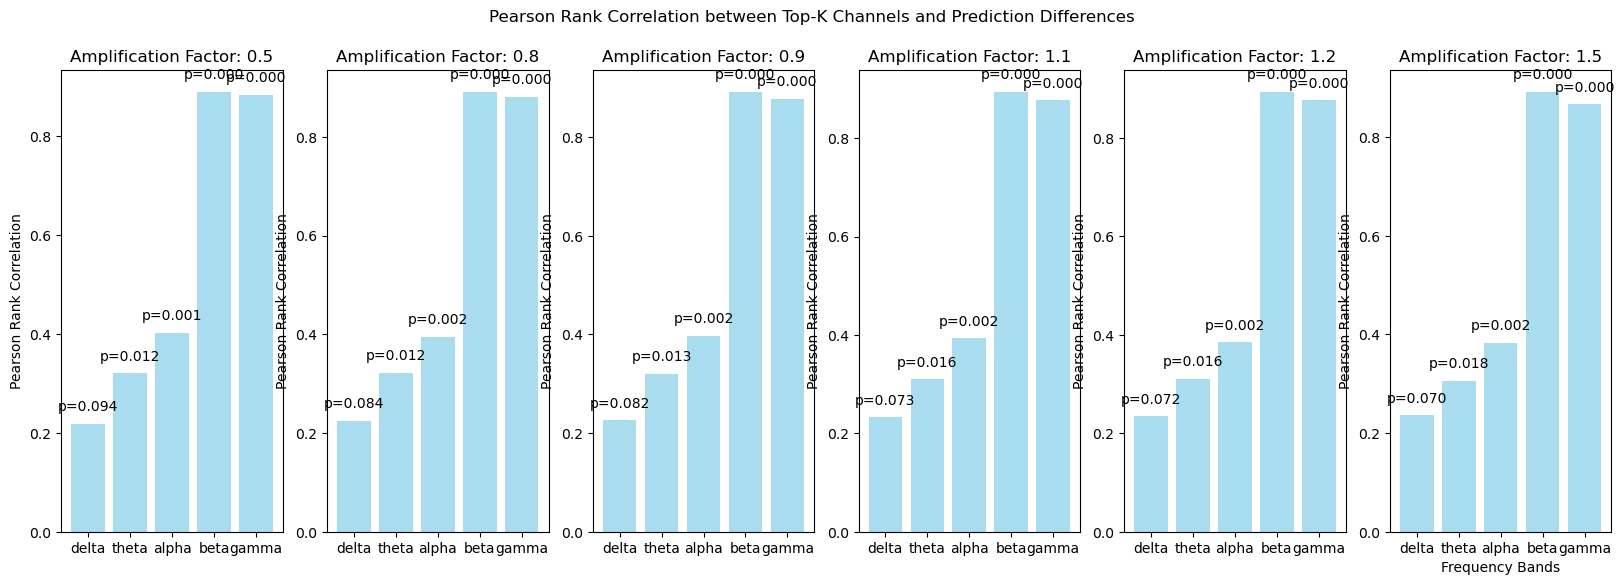

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_041_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_041_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
764 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


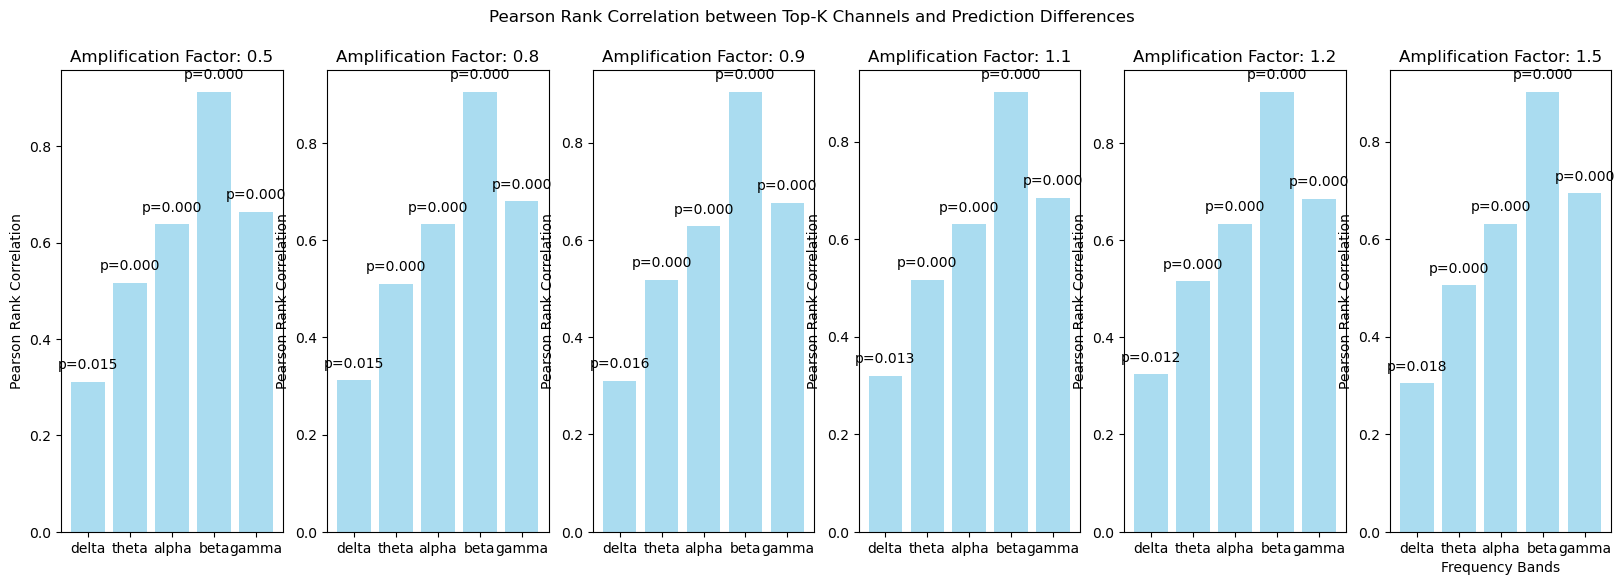

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_042_preprocessed_combined_py.fif ...


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_042_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available
Adding metadata with 1 columns
788 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


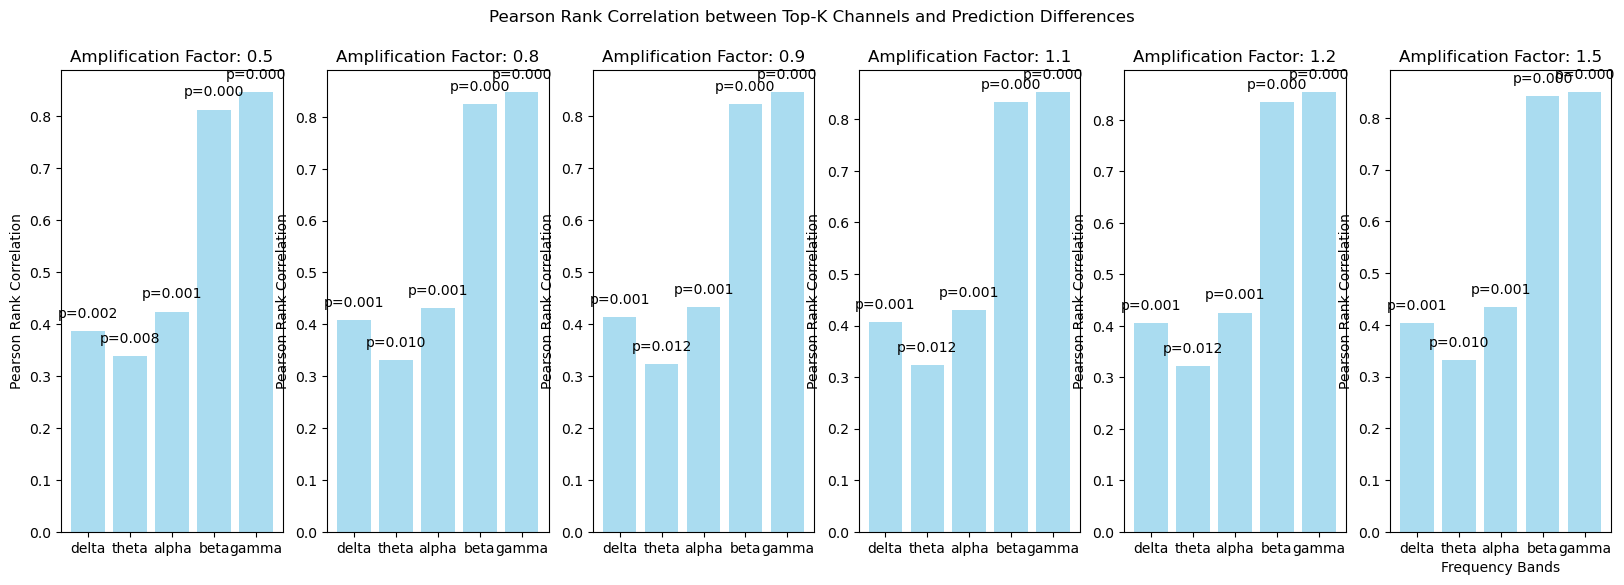

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_043_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_043_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
727 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


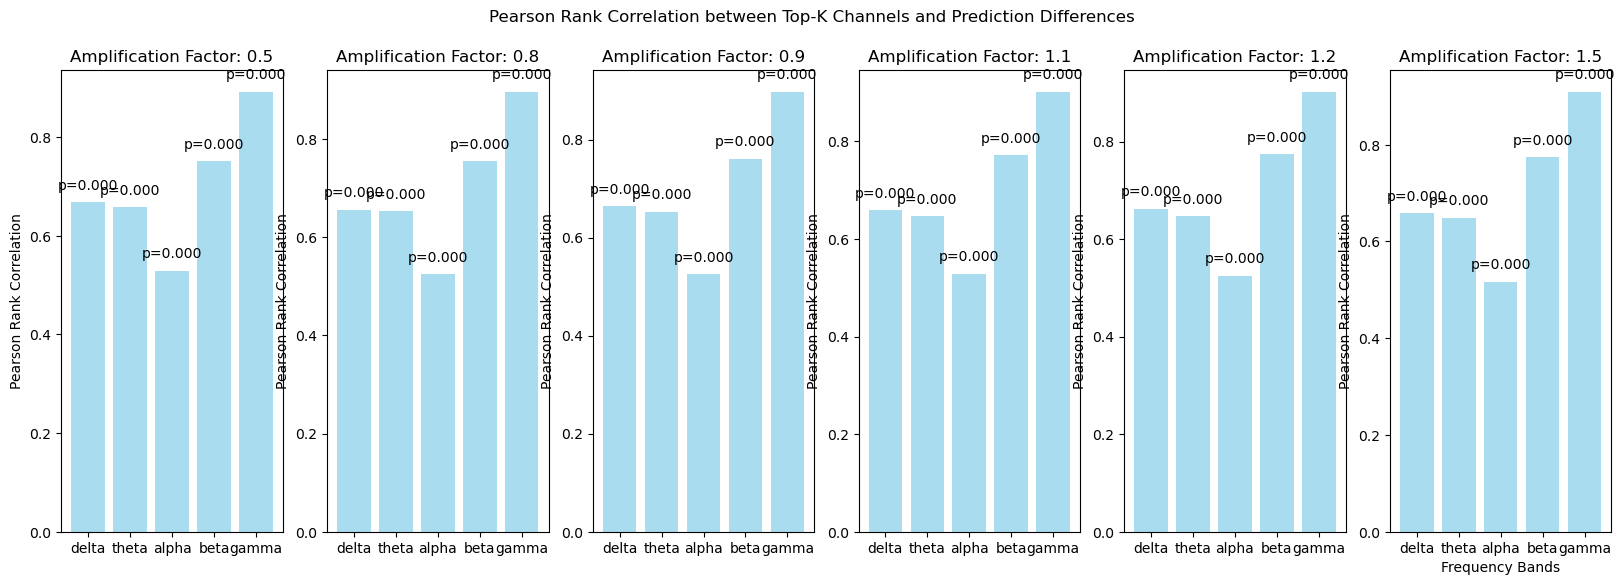

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_045_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_045_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
647 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


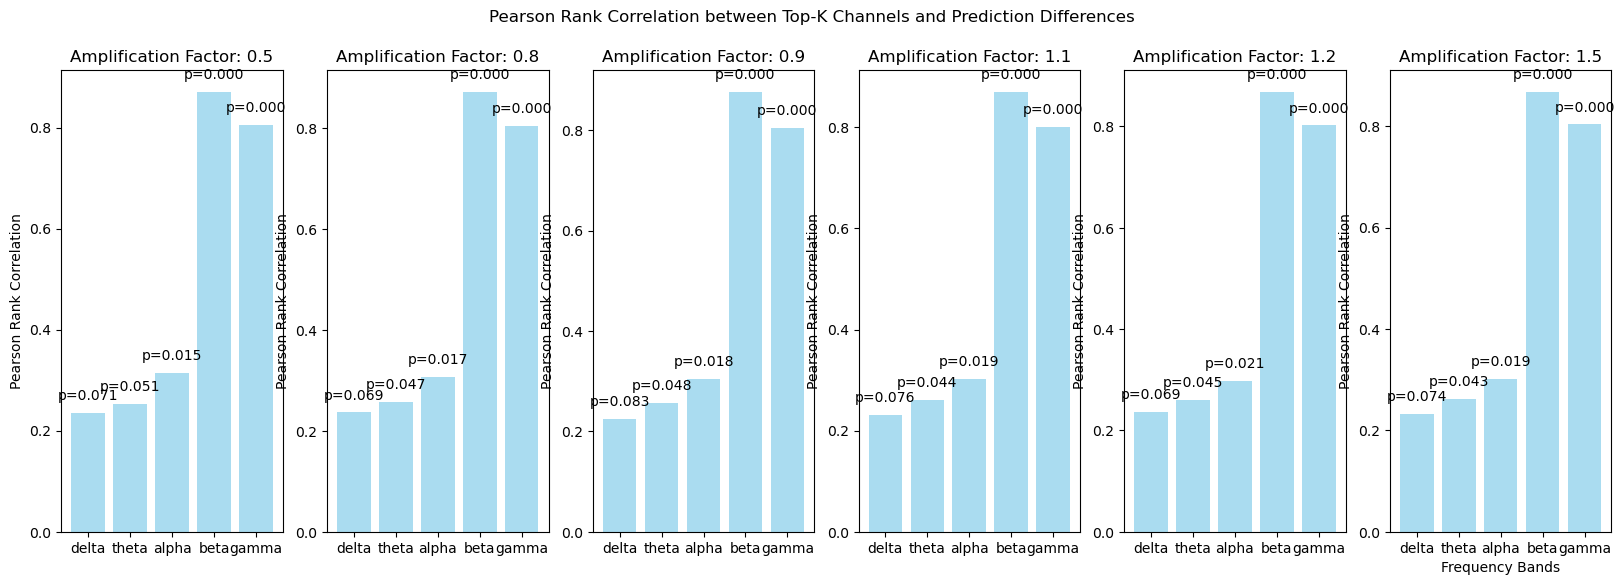

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_046_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_046_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
705 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


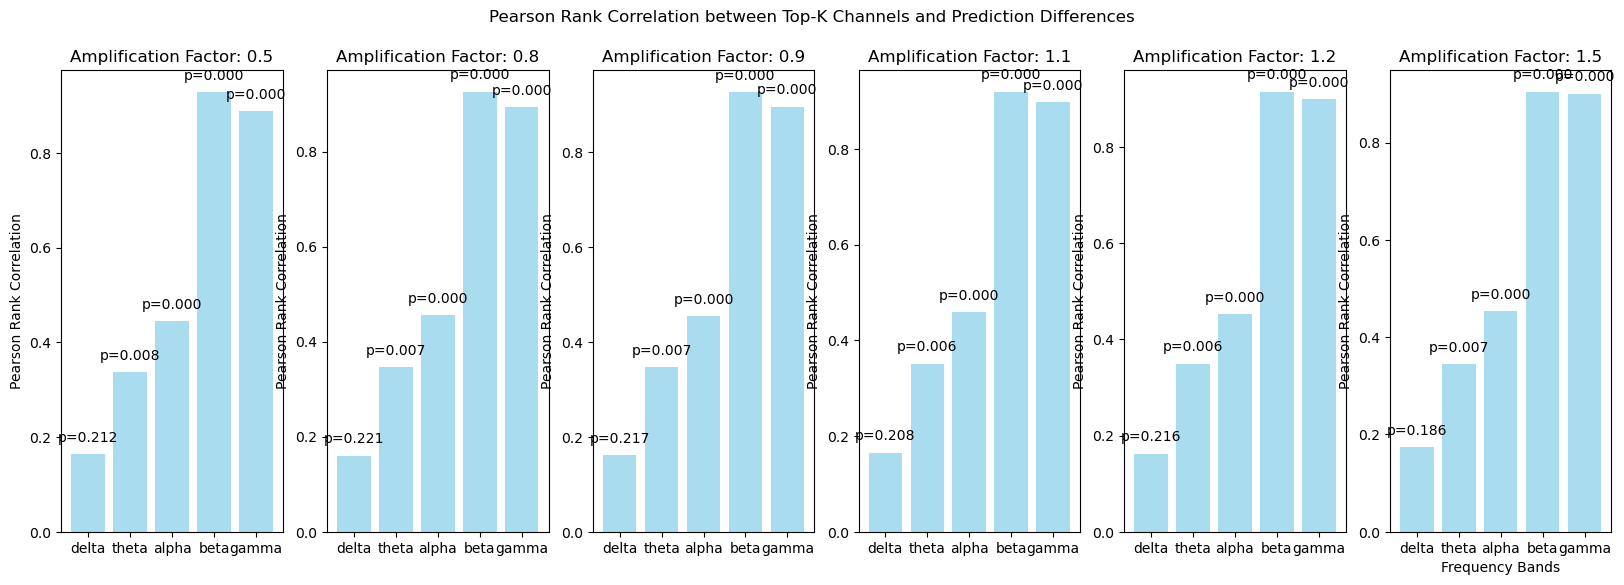

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_047_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_047_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
751 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


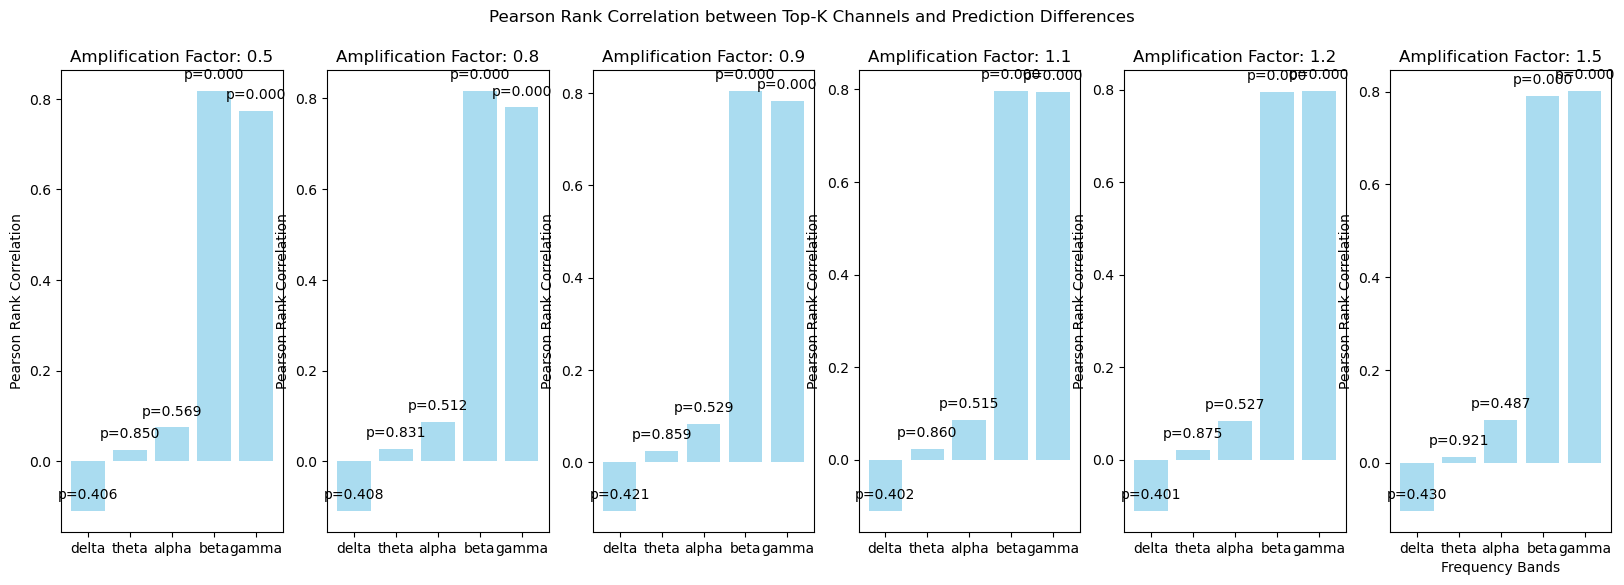

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_048_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_048_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
500 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


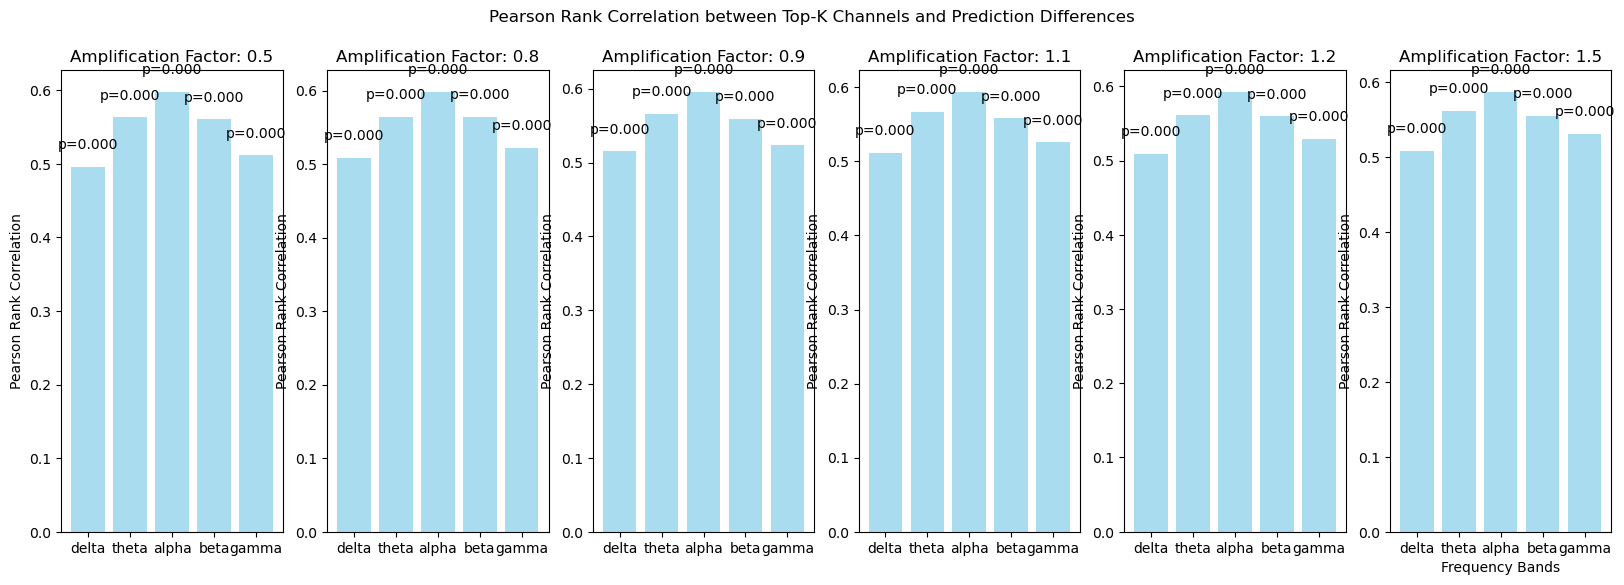

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_052_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_052_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
654 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


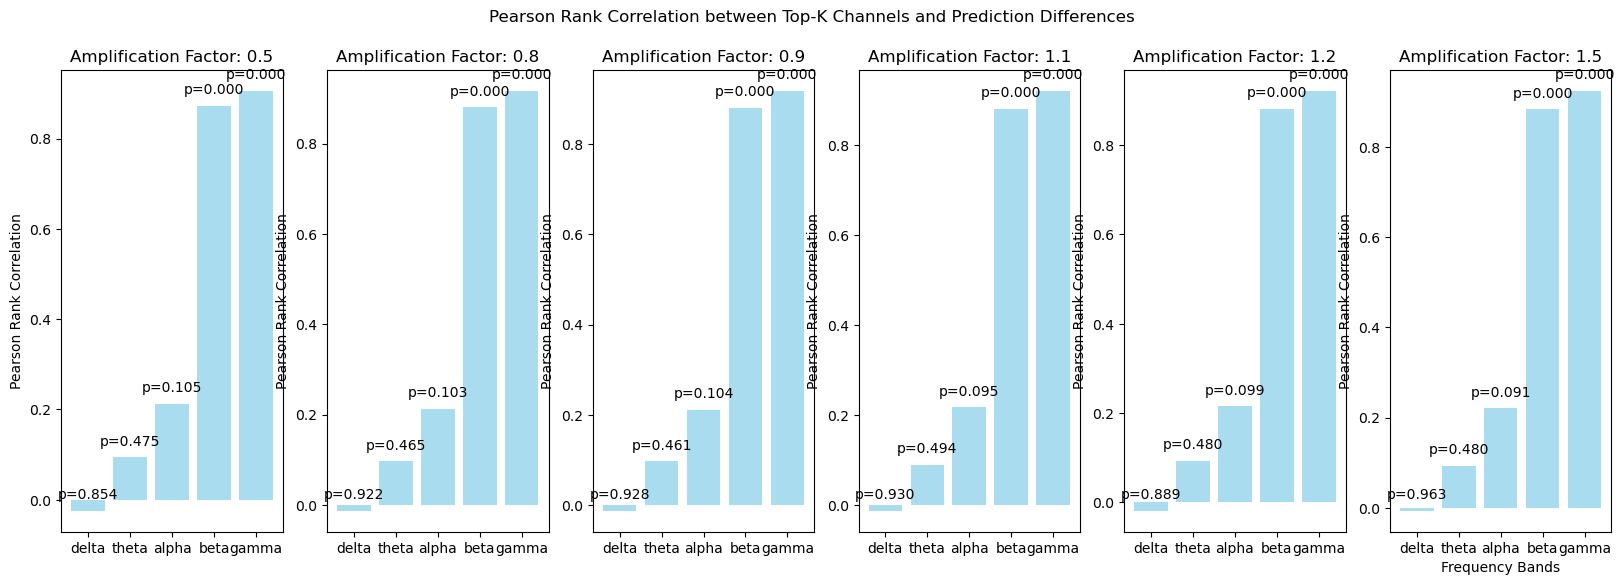

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_055_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_055_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
657 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


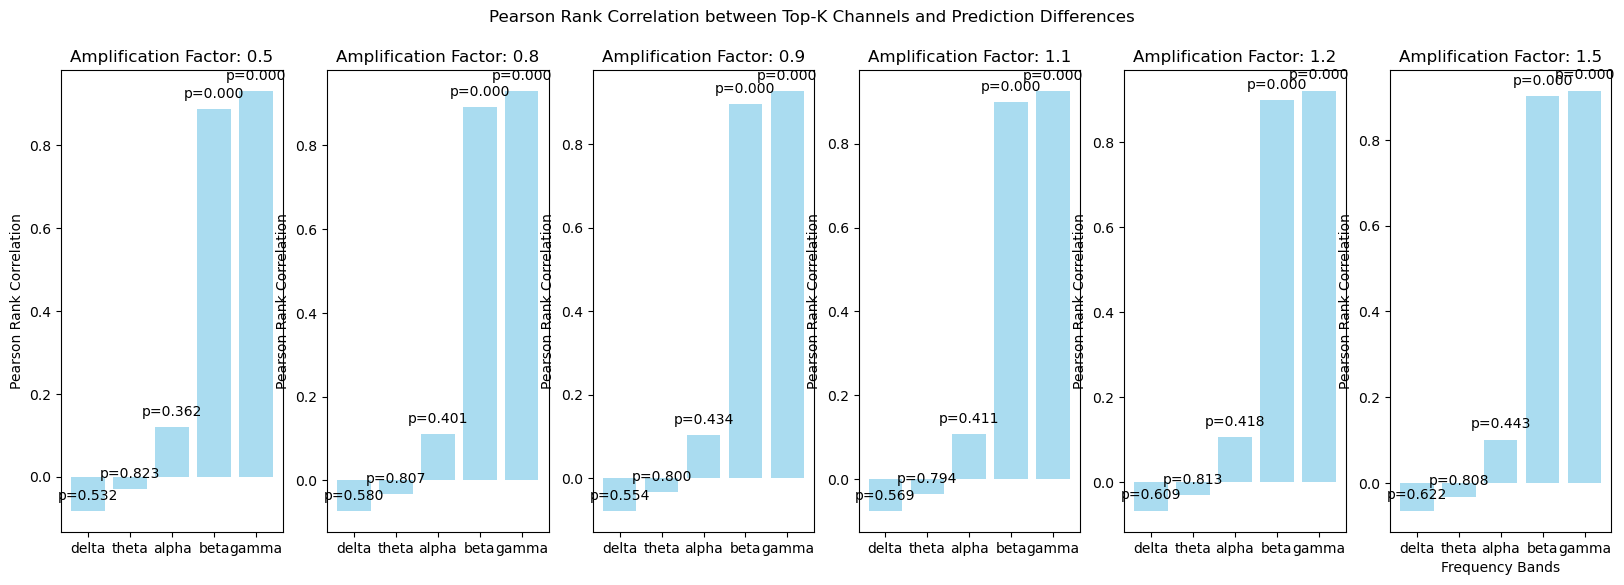

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_056_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_056_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
585 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


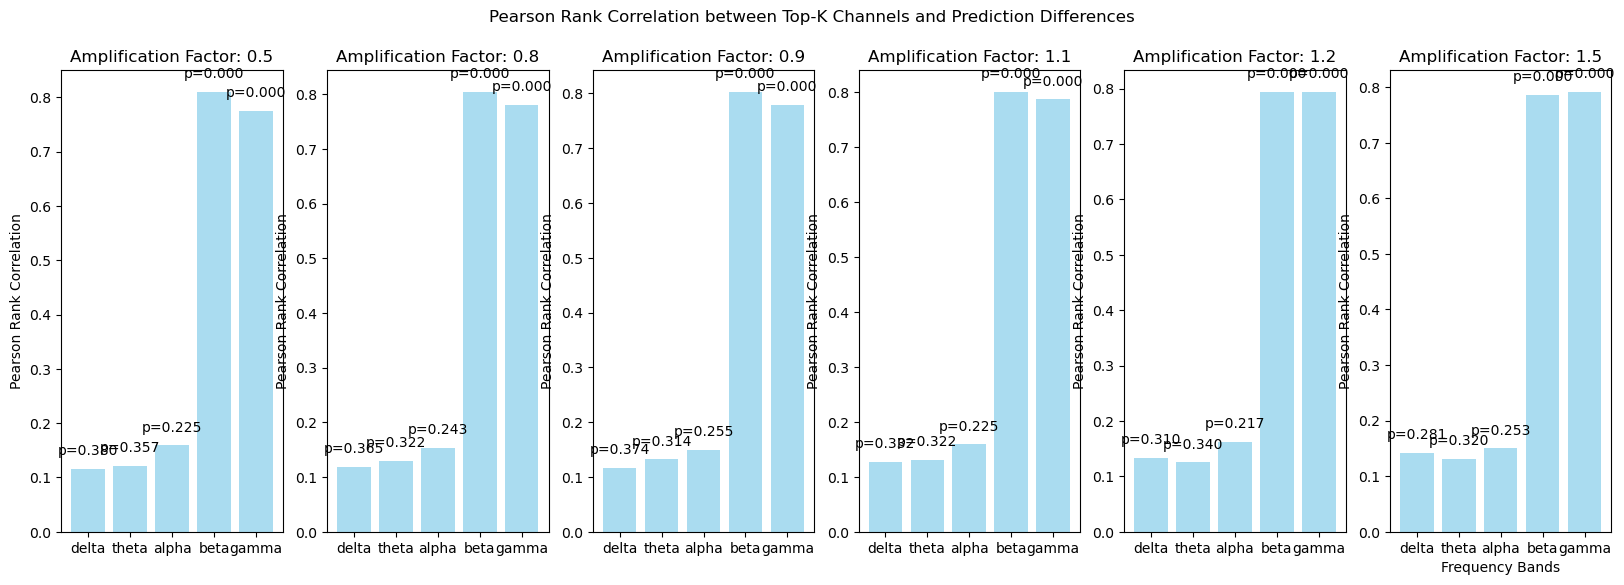

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_057_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_057_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
672 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


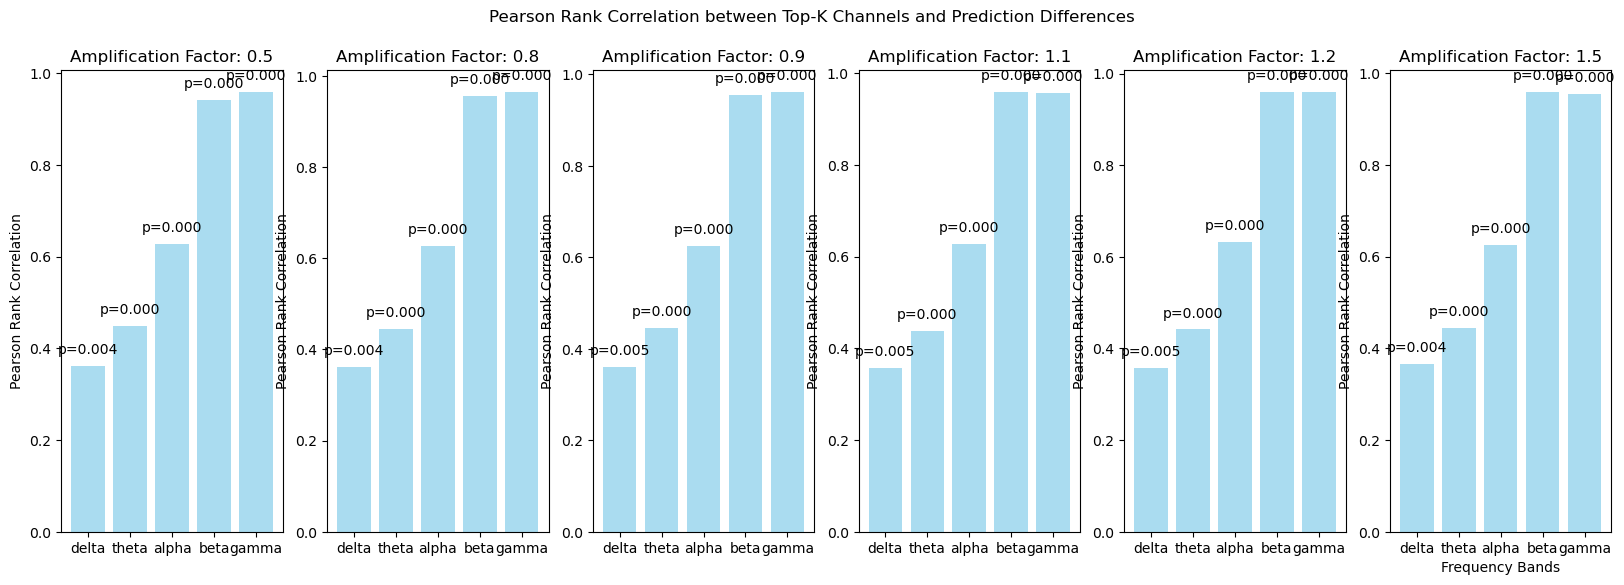

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_060_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_060_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
752 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


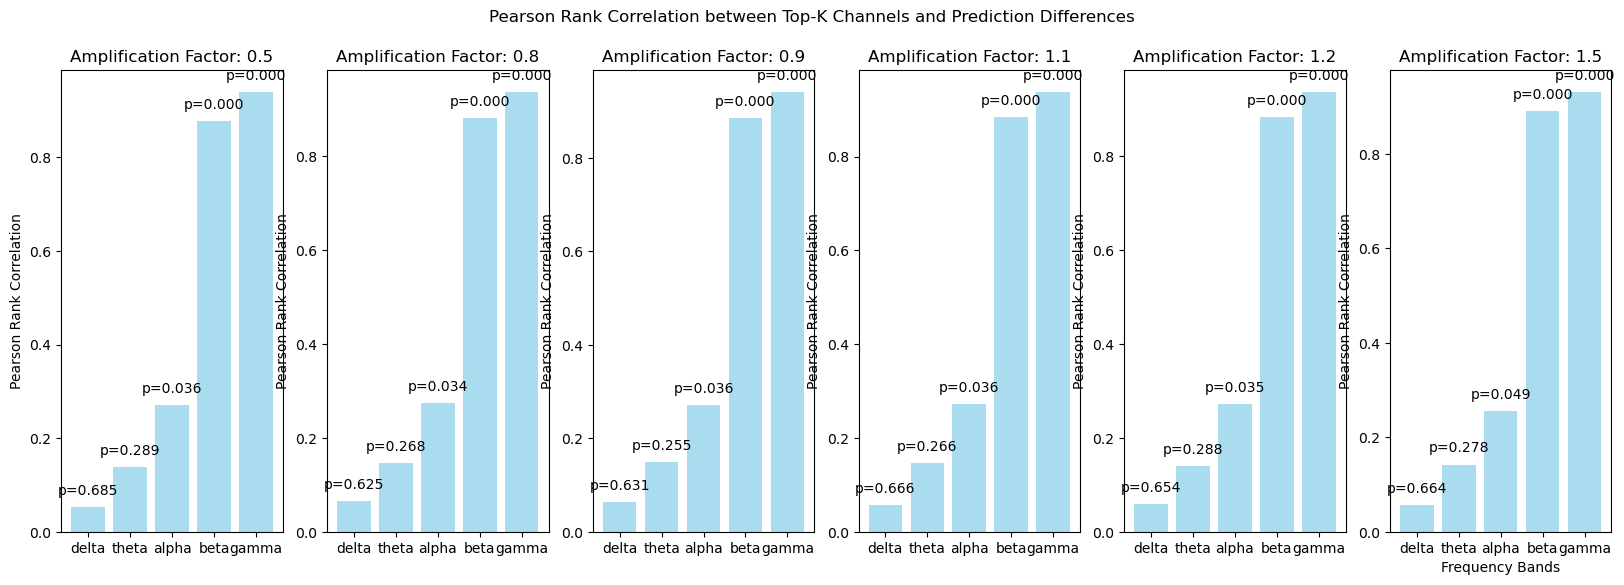

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_062_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_062_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
773 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


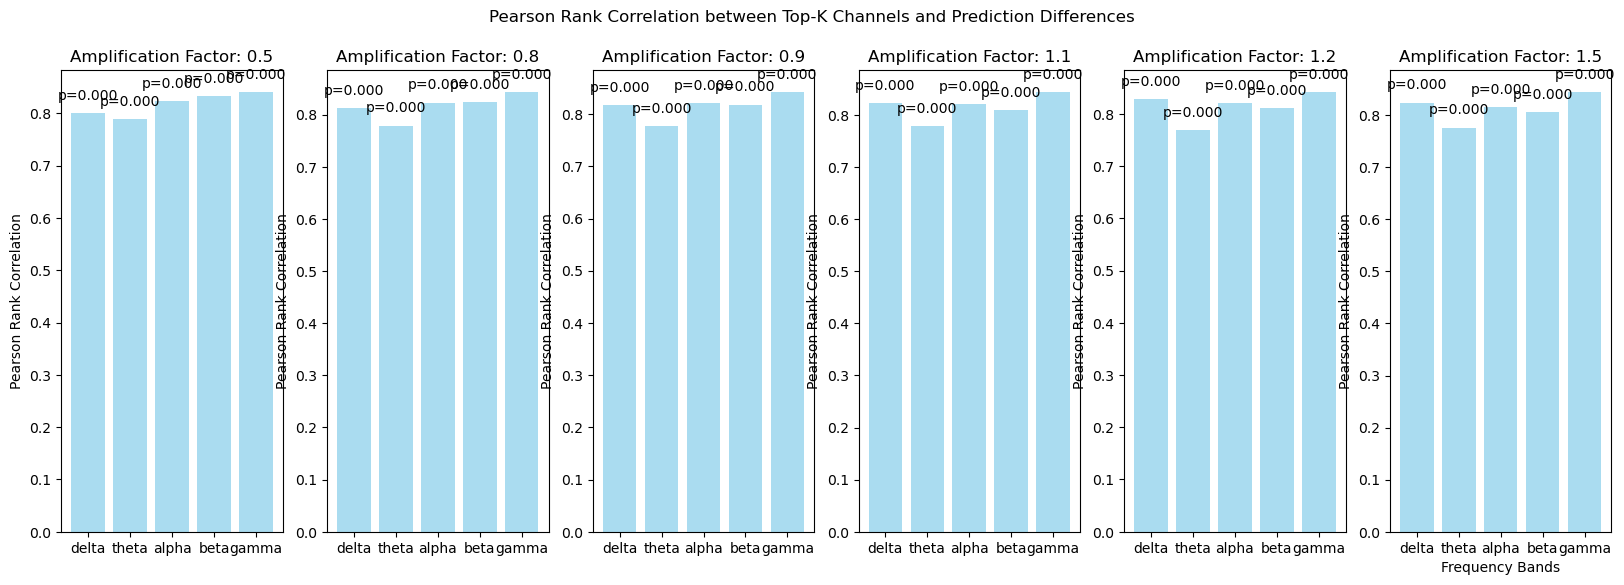

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_067_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_067_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
646 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


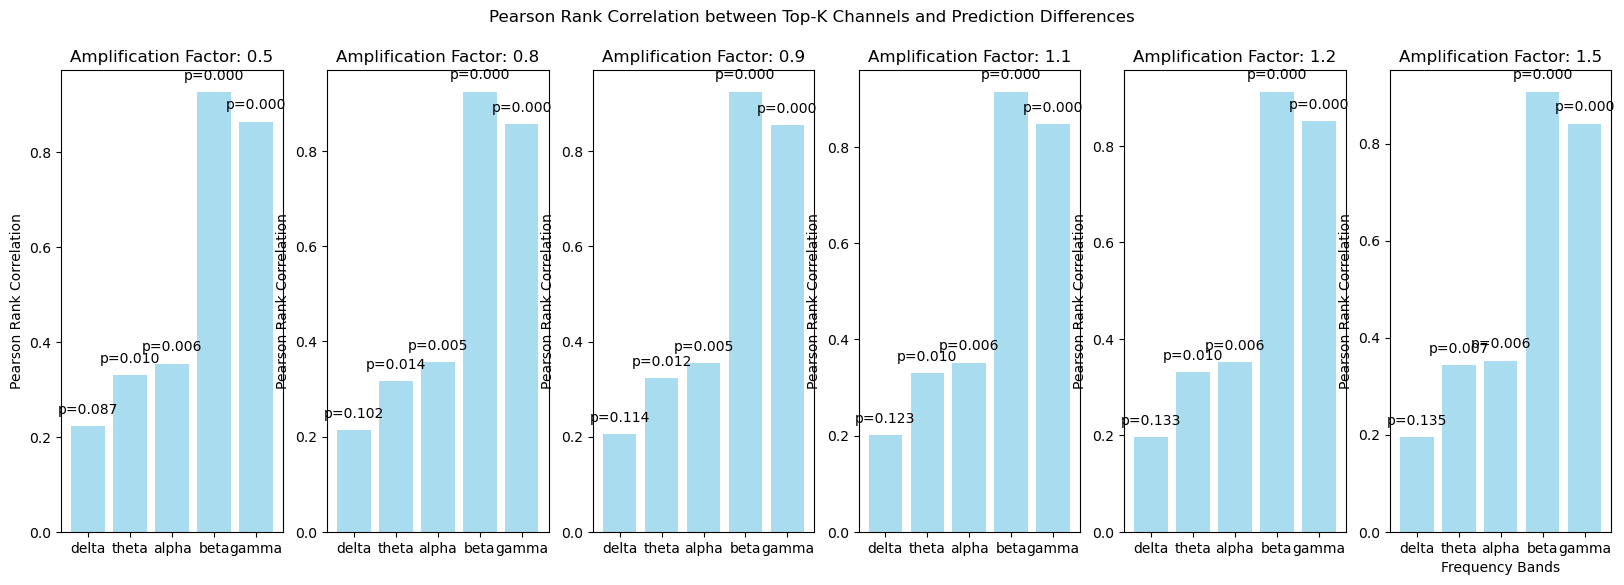

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_069_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_069_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
599 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


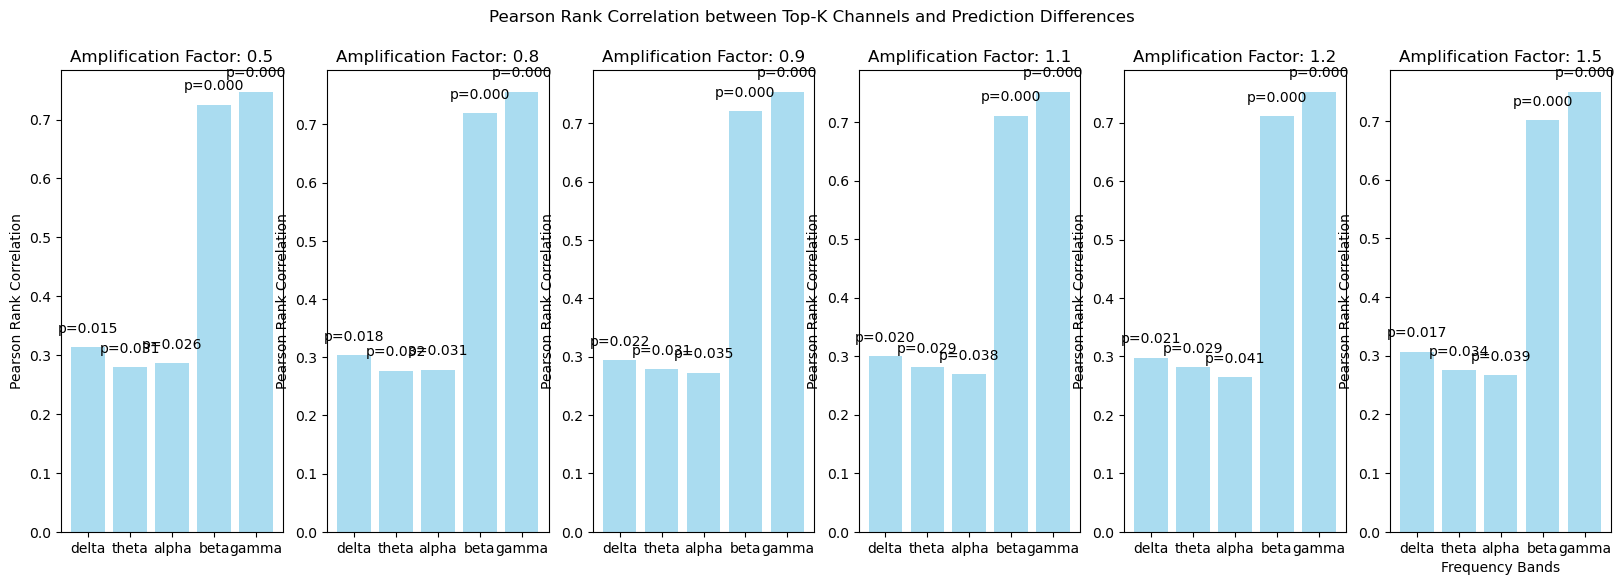

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_072_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_072_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
702 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


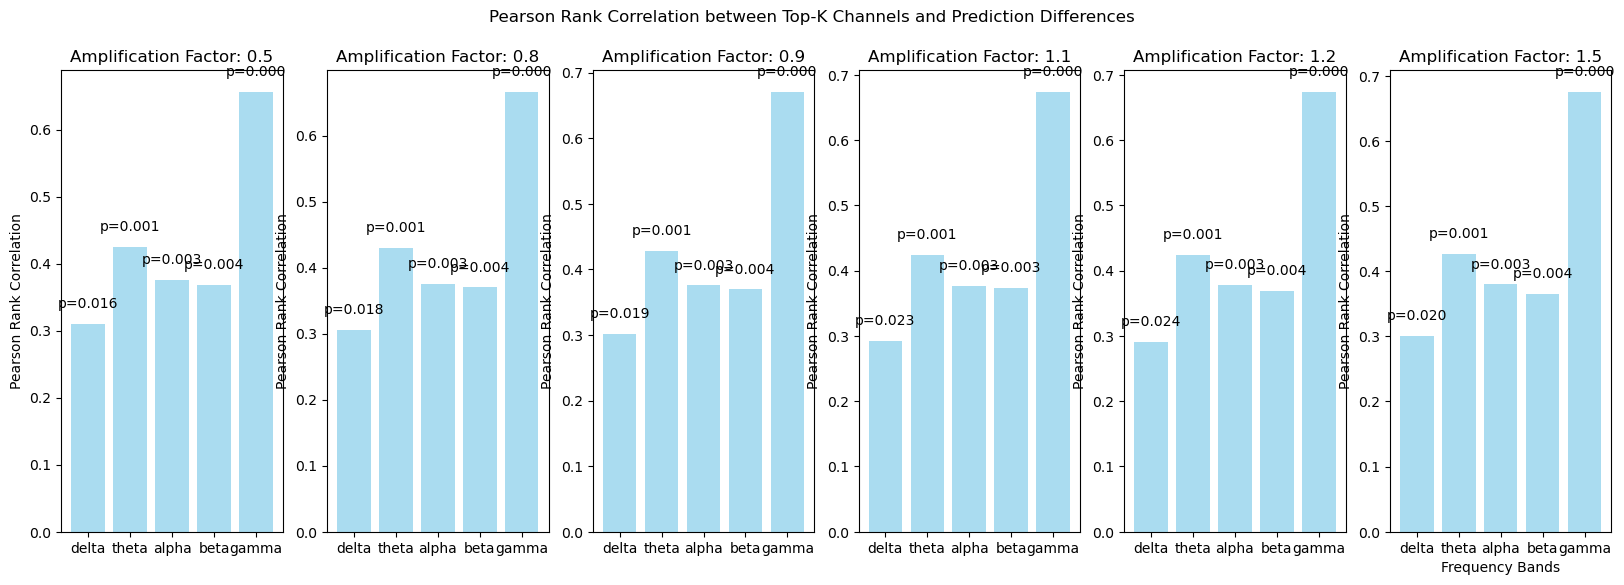

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_073_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_073_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
620 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


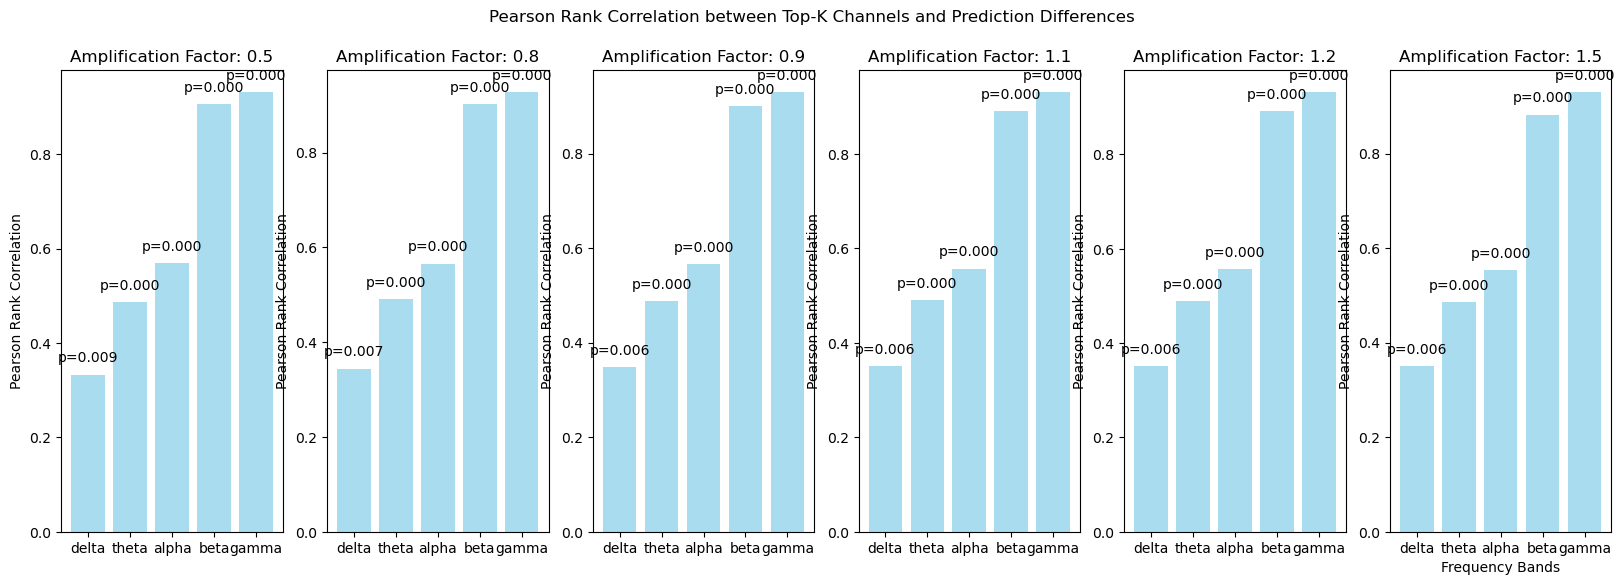

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_079_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_079_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
773 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


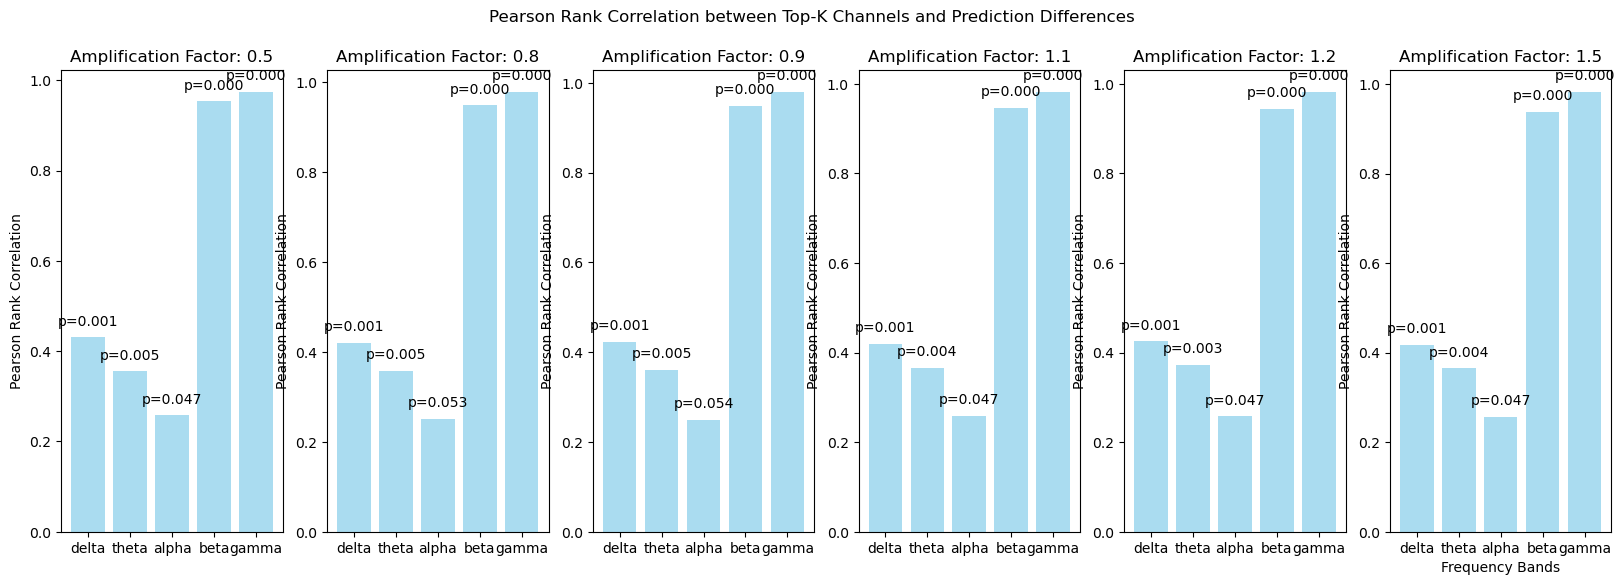

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_080_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_080_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
760 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


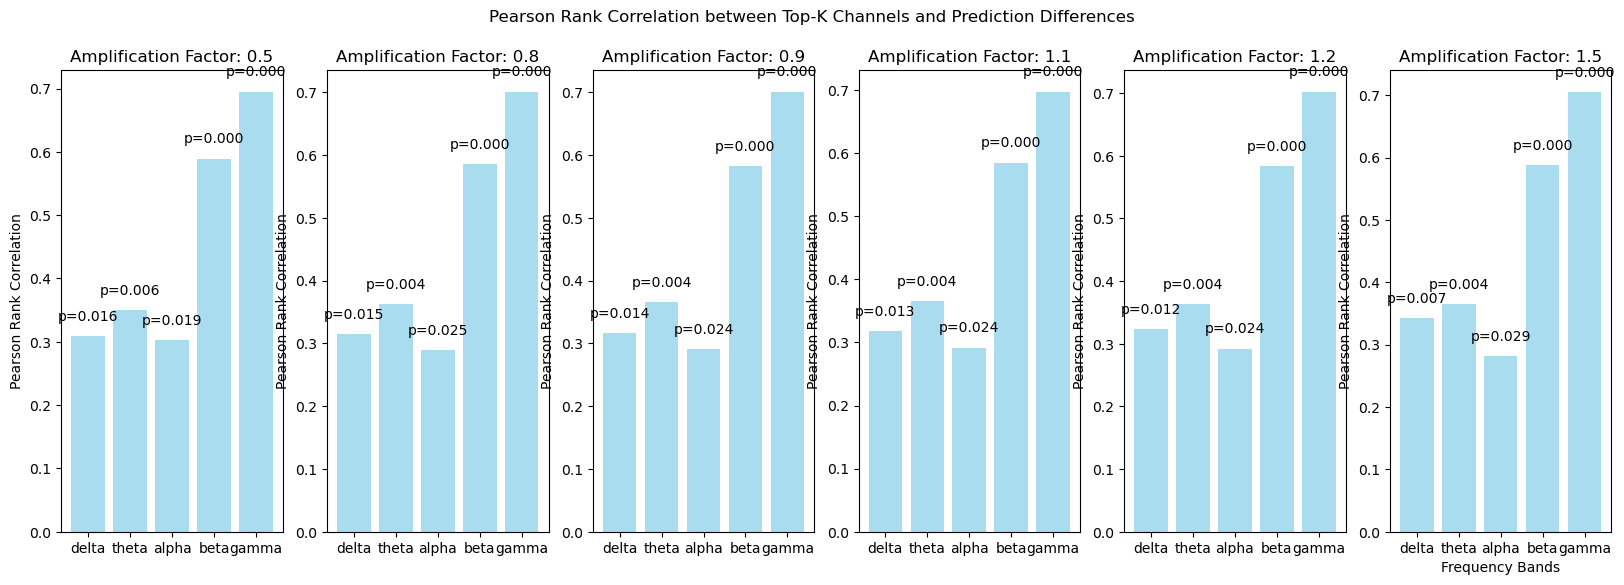

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_086_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_086_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
736 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


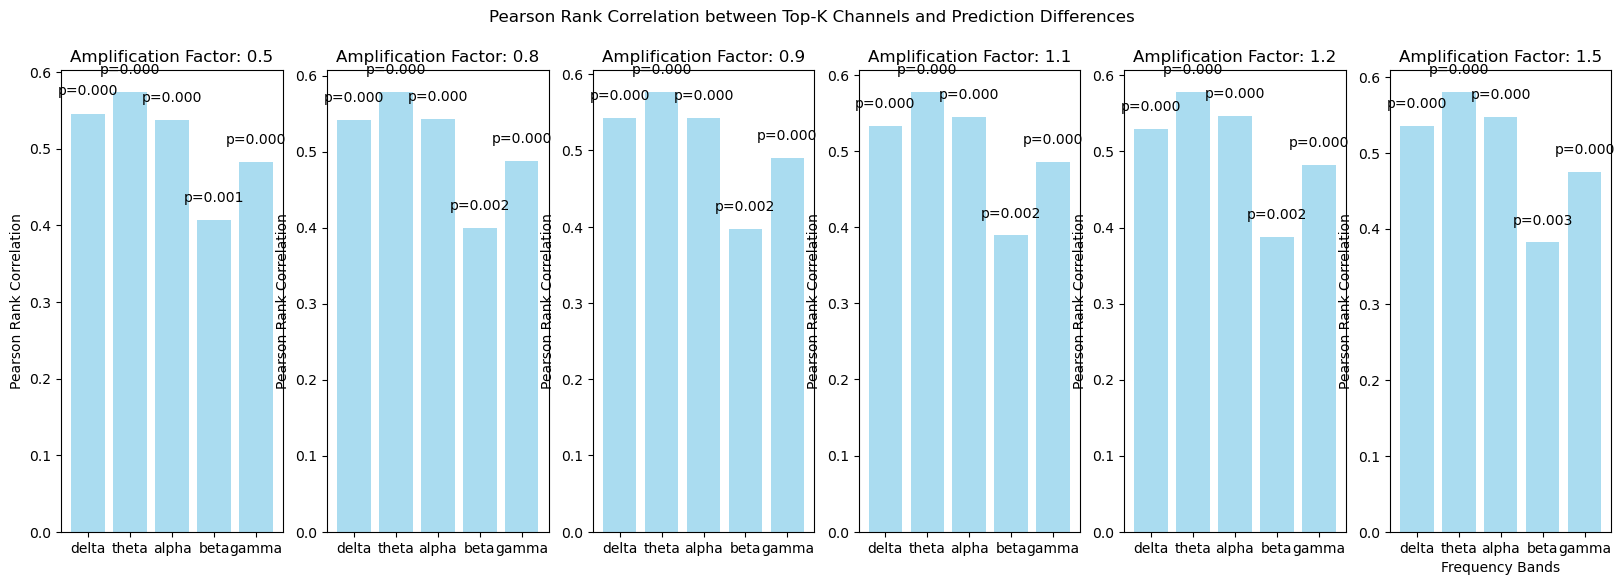

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_088_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_088_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
608 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


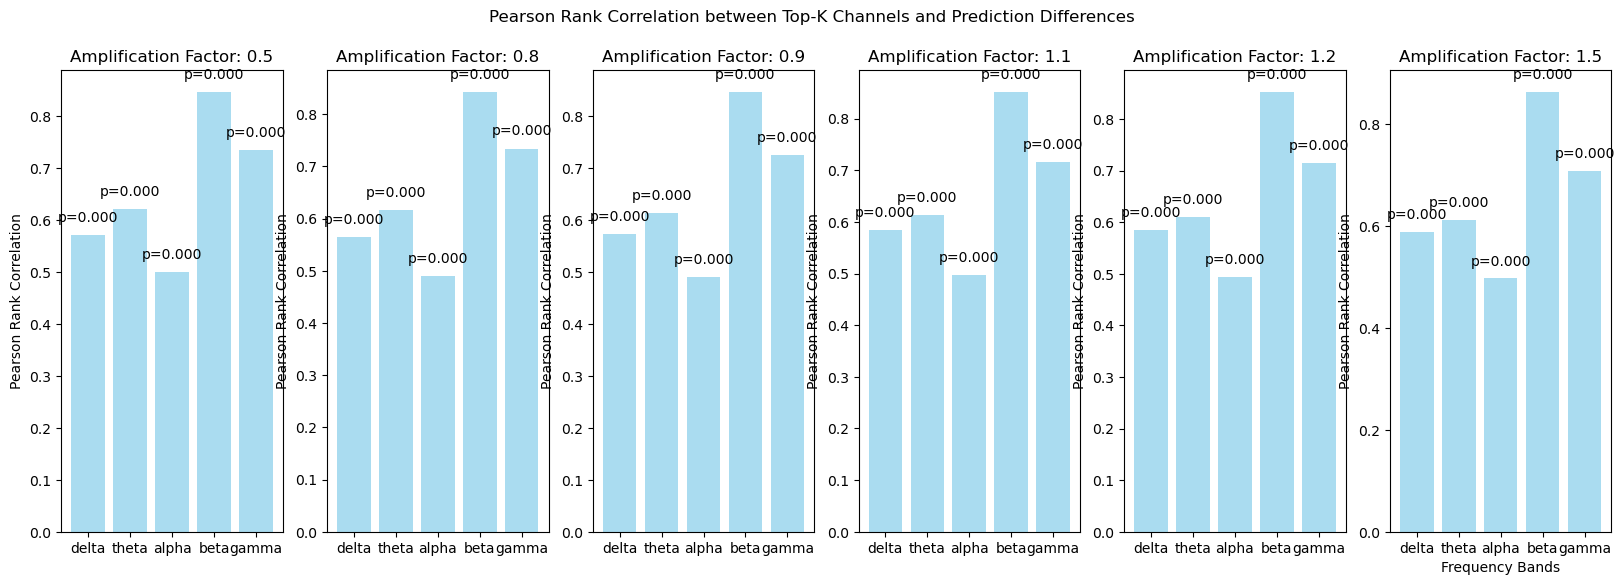

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_092_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_092_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
564 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


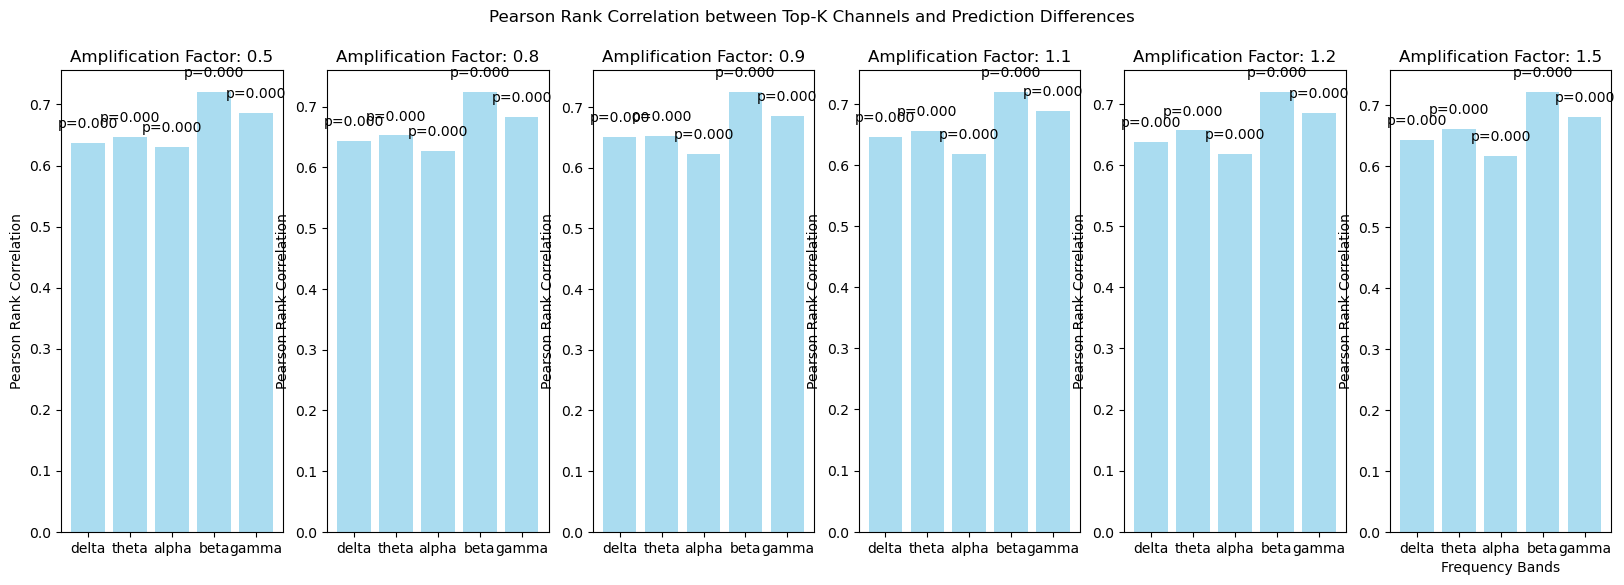

Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_102_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_102_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
789 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


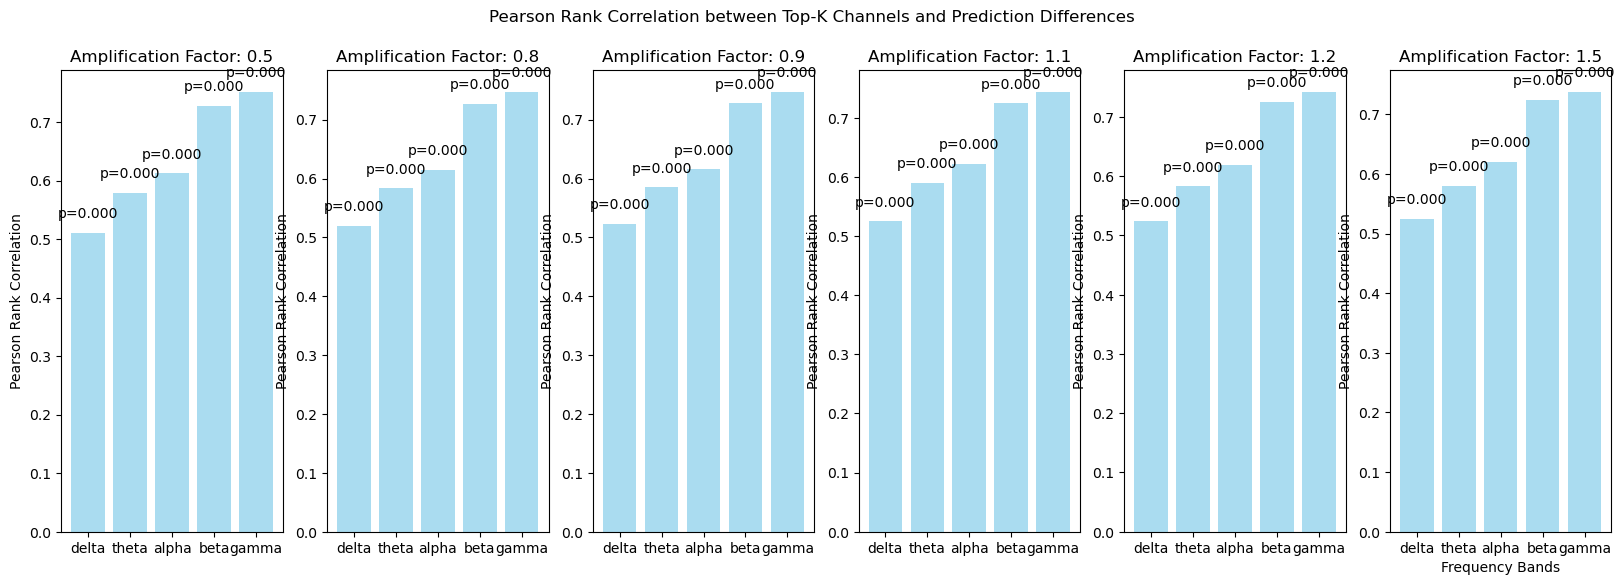

In [21]:
cfg = load_config()
for subject_index in cfg.dataset.test_subject_indices:
    original_predictions, _, explanations, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=1)
    mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, amplification_factors, ch_names, subject_index=subject_index, rep=1)
    prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
    #top_channels_mean, top_channels_median, prediction_diff_mean, prediction_diff_median = get_top_channels(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors, top_k=10)
    top_60 = load_subject_topk(subject_index=subject_index, rep=1)
    calculate_and_plot_rank_correlation(top_60 , prediction_diff_median_unsorted , freq_bands)



while beta and gamma seem significant for all subjects, there seem to be also a group of subjects for which significant rank correlations are found for all frequency bands???

In [25]:

def calculate_average_rank_correlation(cfg, freq_bands, amplification_factors,rep=2):
    """
    Calculate the average rank correlation over all subjects.

    Parameters:
    cfg (omegaconf.dictconfig.DictConfig): Configuration object.
    freq_bands (dict): Dictionary of frequency bands.
    amplification_factors (list): List of amplification factors.

    Returns:
    dict: Average rank correlation results for each frequency band.
    """
    all_correlations = {band: [] for band in freq_bands.keys()}

    for subject_index in cfg.dataset.test_subject_indices:
        original_predictions, _, explanations, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index, rep=rep)
        mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, amplification_factors, ch_names, subject_index=subject_index, rep=rep)
        prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
        top_60 = load_subject_topk(subject_index=subject_index,rep=rep)
        
        # Calculate rank correlation for each frequency band
        for band_name in freq_bands.keys():
            prediction_diff_values = list(prediction_diff_mean_unsorted[band_name][1.5].values())
            top_k_60_values = list(top_60.values())
            correlation, _ = pearsonr(top_k_60_values, prediction_diff_values)
            all_correlations[band_name].append(correlation)

    # Calculate average correlation for each frequency band
    average_correlations = {band: np.nanmean(correlations) for band, correlations in all_correlations.items()}
    std_correlations = {band: np.nanstd(correlations) for band, correlations in all_correlations.items()}
    return average_correlations, std_correlations

def plot_average_rank_correlation(average_correlations):
    """
    Plot the average rank correlation over all subjects.

    Parameters:
    average_correlations (dict): Average rank correlation results for each frequency band.
    """
    bands = list(average_correlations.keys())
    avg_correlations = list(average_correlations.values())

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(bands, avg_correlations, color='skyblue', alpha=0.7)
    ax.set_xlabel('Frequency Bands')
    ax.set_ylabel('Average Pearson Rank Correlation')
    ax.set_title('Average Pearson Rank Correlation over All Subjects')
    plt.savefig("Average_Rank_Correlation_All_Subjects_power.png")
    #plt.show()

# Calculate and plot average rank correlation
average_correlations, std_correlations = calculate_average_rank_correlation(cfg, freq_bands, amplification_factors, rep=1)
#plot_average_rank_correlation(average_correlations)


Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_001_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_001_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
510 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_002_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
721 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_013_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


...

Adding metadata with 1 columns
608 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_092_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_092_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
564 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
Reading /home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_102_preprocessed_combined_py.fif ...
    Found the data of interest:
        t =   -1005.00 ...    -805.20 ms
        0 CTF compensation matrices available


/home/marco/Documents/GitHub/tms_eeg_decoding/perturb_samples_power/data/data_loader.py:41: RuntimeWarning: This filename (/home/marco/Documents/GitHub/tms_eeg_decoding/data/subject_102_preprocessed_combined_py.fif) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(file_path) # (trials, channels, timepoints)


Adding metadata with 1 columns
789 matching events found
No baseline correction applied
0 projection items activated
(100, 60, 900)
(1, 60, 1)


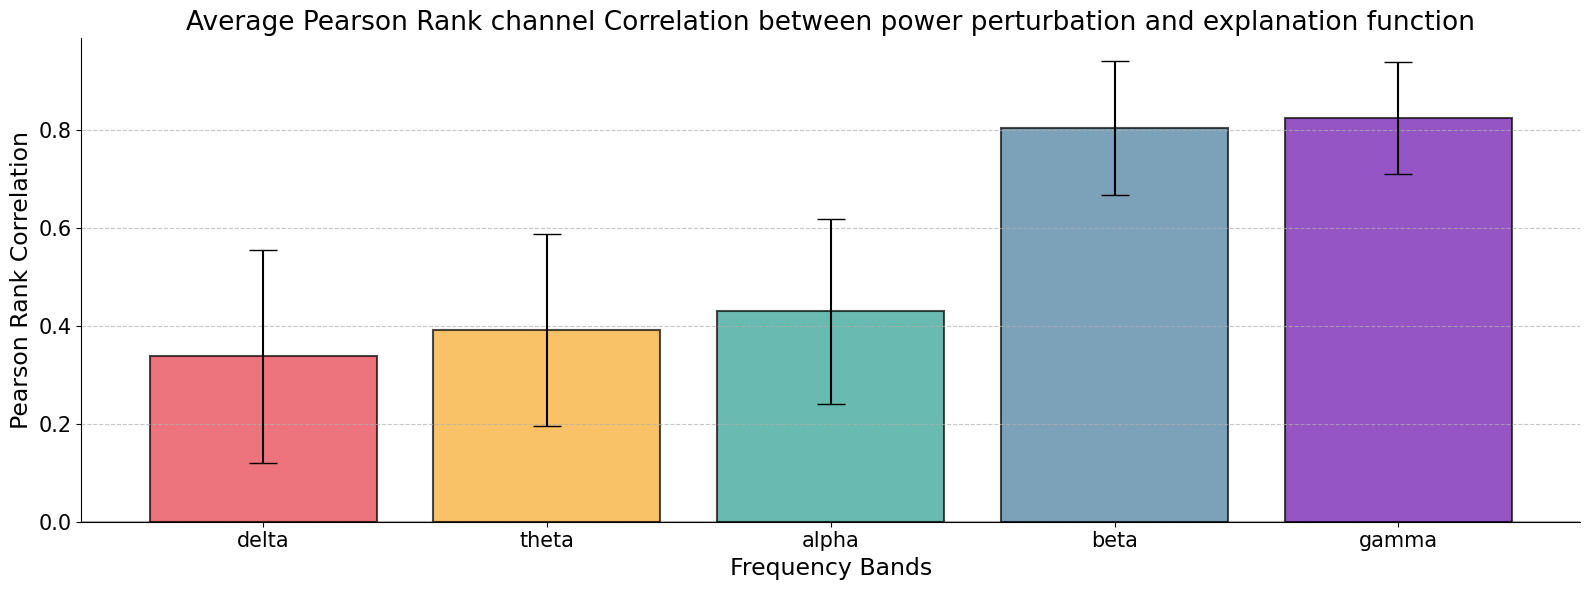

In [32]:
def plot_average_rank_correlation(average_correlations, std_correlations):
    """
    Plot the average rank correlation over all subjects with error bars.

    Parameters:
    average_correlations (dict): Average rank correlation results for each frequency band.
    std_correlations (dict): Standard deviation of correlations for each frequency band.
    """
    bands = list(average_correlations.keys())
    avg_correlations = list(average_correlations.values())
    std_devs = list(std_correlations.values())
    
    # Create a color palette
    colors = {
        'delta': '#E63946',  # Crimson red
        'theta': '#F9A826',  # Orange
        'alpha': '#2A9D8F',  # Teal
        'beta':  '#457B9D',  # Blue
        'gamma': '#6A0DAD',  # Purple
    }
    
    # Get colors in the correct order based on bands
    bar_colors = [colors[band] for band in bands]
    
    fig, ax = plt.subplots(figsize=(16, 6))
    
    # Create the bar plot with error bars
    bars = ax.bar(bands, avg_correlations, yerr=std_devs, capsize=10, 
                alpha=0.7, color=bar_colors, edgecolor='black', linewidth=1.5)
    
    # Customize the plot
    ax.set_xlabel('Frequency Bands', fontsize=17)
    ax.set_ylabel('Pearson Rank Correlation', fontsize=17)
    ax.set_title('Average Pearson Rank channel Correlation between power perturbation and explanation function', fontsize=19)
    

    
    # Improve appearance
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=15)
    
    # Add a horizontal line at y=0
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig("Average_Rank_Correlation_All_Subjects_power_with_errorbars.png", dpi=300, bbox_inches='tight')
    plt.show()

# Calculate and plot average rank correlation
plot_average_rank_correlation(average_correlations, std_correlations)


Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)
(1, 60, 1)
Loading EEG data...
(100, 60, 900)

/tmp/ipykernel_3541394/3080550755.py:61: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(distance_matrix, method='ward')


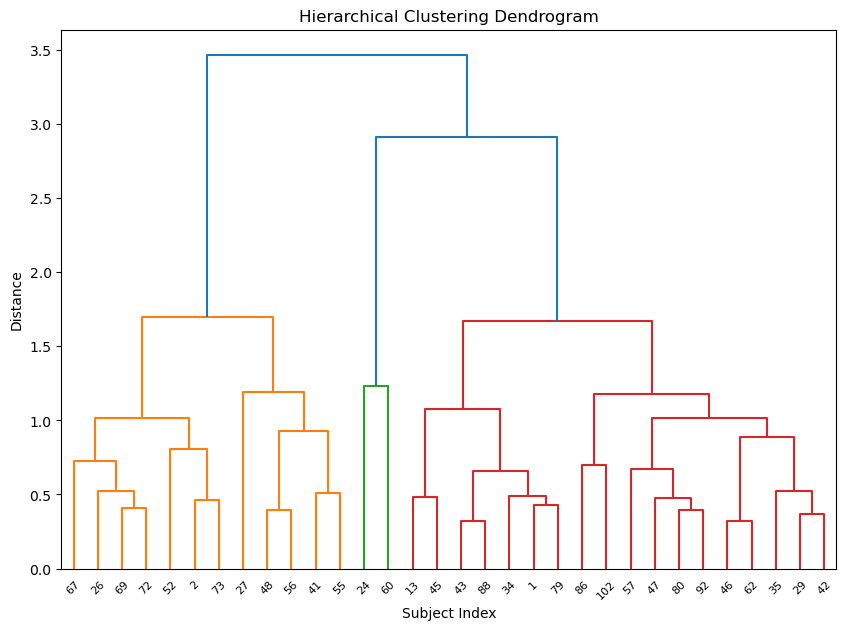

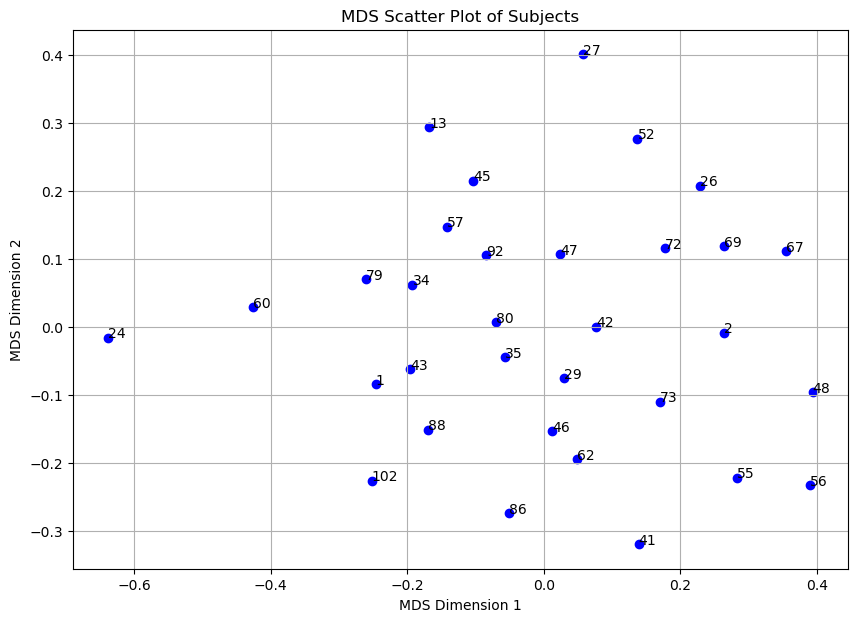

In [54]:
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
import seaborn as sns
from sklearn.manifold import MDS

def calculate_correlation_statistics(cfg, freq_bands, amplification_factors):
    """
    Calculate the correlation statistics for each subject.

    Parameters:
    cfg (omegaconf.dictconfig.DictConfig): Configuration object.
    freq_bands (dict): Dictionary of frequency bands.
    amplification_factors (list): List of amplification factors.

    Returns:
    dict: Correlation statistics for each subject.
    """
    correlation_statistics = {}

    for subject_index in cfg.dataset.test_subject_indices:
        original_predictions, _, explanations, ch_names = load_predicted_amplitude_for_subject(subject_index=subject_index)
        mean_diff_per_channel, median_diff_per_channel = calculate_diff_per_channel(original_predictions, freq_bands, amplification_factors, ch_names, subject_index=subject_index)
        prediction_diff_mean_unsorted, prediction_diff_median_unsorted = get_prediction_diff(mean_diff_per_channel, median_diff_per_channel, freq_bands, amplification_factors)
        top_60 = load_subject_topk(subject_index=subject_index)
        
        # Calculate rank correlation for each frequency band
        correlation_results = {}
        for band_name in freq_bands.keys():
            prediction_diff_values = list(prediction_diff_mean_unsorted[band_name][3].values())
            top_k_60_values = list(top_60.values())
            correlation, _ = pearsonr(top_k_60_values, prediction_diff_values)
            correlation_results[band_name] = correlation
        
        correlation_statistics[subject_index] = correlation_results

    return correlation_statistics

def compute_distance_matrix(correlation_statistics):
    """
    Compute the pairwise distance matrix between subjects based on their correlation statistics.

    Parameters:
    correlation_statistics (dict): Correlation statistics for each subject.

    Returns:
    np.ndarray: Pairwise distance matrix.
    """
    subjects = list(correlation_statistics.keys())
    correlation_vectors = [list(correlation_statistics[subject].values()) for subject in subjects]
    distance_matrix = squareform(pdist(correlation_vectors, metric='euclidean'))
    return distance_matrix, subjects

def cluster_subjects(distance_matrix, subjects):
    """
    Perform clustering on the distance matrix and plot the dendrogram.

    Parameters:
    distance_matrix (np.ndarray): Pairwise distance matrix.
    subjects (list): List of subject indices.
    """
    linkage_matrix = linkage(distance_matrix, method='ward')
    plt.figure(figsize=(10, 7))
    dendrogram(linkage_matrix, labels=subjects)
    plt.title('Hierarchical Clustering Dendrogram')
    plt.xlabel('Subject Index')
    plt.ylabel('Distance')
    plt.show()

# Calculate correlation statistics for each subject
correlation_statistics = calculate_correlation_statistics(cfg, freq_bands, distances)

# Compute the pairwise distance matrix
distance_matrix, subjects = compute_distance_matrix(correlation_statistics)

# Perform clustering and plot the dendrogram
cluster_subjects(distance_matrix, subjects)

def plot_mds_scatter(distance_matrix, subjects):
    """
    Perform MDS and plot the results in a 2D scatter plot.

    Parameters:
    distance_matrix (np.ndarray): Pairwise distance matrix.
    subjects (list): List of subject indices.
    """
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
    mds_coords = mds.fit_transform(distance_matrix)

    plt.figure(figsize=(10, 7))
    plt.scatter(mds_coords[:, 0], mds_coords[:, 1], c='blue', marker='o')

    for i, subject in enumerate(subjects):
        plt.annotate(subject, (mds_coords[i, 0], mds_coords[i, 1]))

    plt.title('MDS Scatter Plot of Subjects')
    plt.xlabel('MDS Dimension 1')
    plt.ylabel('MDS Dimension 2')
    plt.grid(True)
    plt.show()

# Plot the MDS scatter plot
plot_mds_scatter(distance_matrix, subjects)